##### ANALISIS SENTIMEN KOMENTAR YOUTUBE PADA KONTEN PERTANIAN BERDASARKAN PENDEKATAN NATURAL LANGUAGE PROCESSING (NLP)

IMPORT LIBRARY

In [ ]:
import os
import re
import csv
import nltk
import html
import time
import random
import warnings
import psycopg2
import numpy as np
import pandas as pd
import seaborn as sns
import streamlit as st
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.svm import SVC
from textblob import TextBlob
from collections import Counter, defaultdict
from nltk.corpus import stopwords
from sklearn.svm import LinearSVC
from nltk.tokenize import word_tokenize
from sqlalchemy import create_engine, text
from sklearn.pipeline import make_pipeline
from wordcloud import WordCloud, STOPWORDS
from googleapiclient.discovery import build
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from nltk.tokenize import TreebankWordTokenizer
from tensorflow.keras.utils import to_categorical
from ipywidgets import interact, widgets, Dropdown
from sklearn.neighbors import KNeighborsClassifier
from textblob.classifiers import NaiveBayesClassifier
from sklearn.model_selection import train_test_split
from sklearn.exceptions import UndefinedMetricWarning
from nltk.sentiment import SentimentIntensityAnalyzer
from tensorflow.keras.preprocessing.text import Tokenizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.decomposition import LatentDirichletAllocation
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
warnings.filterwarnings("ignore") 
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

DATABASE POSTGRESQL

In [ ]:
DB_NAME = "agrisentiment"
DB_USER = "postgres"
DB_PASSWORD = #"your_password_here"
DB_HOST = "localhost"
DB_PORT = "5432"

conn = psycopg2.connect(
    dbname="postgres",  
    user=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT
)

conn.autocommit = True
cur = conn.cursor()

cur.execute(f"SELECT 1 FROM pg_database WHERE datname = '{DB_NAME}'")
exists = cur.fetchone()

if not exists:
    cur.execute(f"CREATE DATABASE {DB_NAME}")
    print(f"Database {DB_NAME} berhasil dibuat.")
else:
    print(f"Database {DB_NAME} sudah ada.")

cur.close()
conn.close()

Database agrisentiment berhasil dibuat.


CRAWLING DATA KOMENTAR YOUTUBE

In [ ]:
# from googleapiclient.discovery import build
# import pandas as pd
# import time

# API_KEY = "YouTube API Key"
# youtube = build("youtube", "v3", developerKey=API_KEY)

# # TOPIK & VIDEO ID 

# topics_videos = {
#     "pengendalian hama": [
#         "JTEhv7JCRF0", "GzdFV_r-SHM", "JL2VZdA9wuc", "Xrbn47ZiFYw", 
#         "M0KYwjW-22c", "bOsToXOFK4A", "_lAVXCvou78", "pO43PBserhU"
#     ],
#     "Pemupukan": [
#         "Z3QfdLBjRWk", "28Eo_Xm8LYg", "UfbQxFXre5Q", "inF984LZKa0", 
#         "TCRV_d27iG0", "-YlHpqcgOow", "QQM9BKY0_K8", "4CTYII_qHCQ"
#     ],
#     "Irigasi": [
#         "kS16kRKYJGg", "CKlWtn_c7Es", "59vXGu65IS4", "AQLcjhHQBC0", 
#         "i86gVDwhNzg", "MGpF_mdUVTg", "e0SHDMs4bDk", "_99fDKfRq50",
#     ],
#     "budidaya organik": [
#         "YxYvJhEqC98", "3MeyTr2kdBg", "5Fv2tGv9_Vo", "vvcBT2Fg5IQ", 
#         "ucfHy84xvec", "iArT8RhBxzY", "ypbdbIGDYGw", "G1MjF639DrY",
#     ],
#     "Hidroponik": [
#         "1NnDgJzBAq4", "mLdvwruqEpo", "DcG3sqwpSa0", "GO6PuKMedeM", 
#         "9zyK_C4g4qU", "-GyJN1tr9RM", "y5B5sxJYEOI", "zOKZCuwjWi8"
#     ]
# }

# # AMBIL SEMUA KOMENTAR VIDEO

# def get_all_comments(video_id):
#     comments = []
#     next_page_token = None

#     while True:
#         try:
#             request = youtube.commentThreads().list(
#                 part="snippet",
#                 videoId=video_id,
#                 maxResults=100,
#                 textFormat="plainText",
#                 pageToken=next_page_token
#             )
#             response = request.execute()

#             for item in response.get("items", []):
#                 snippet = item["snippet"]["topLevelComment"]["snippet"]
#                 comments.append({
#                     "video_id": video_id,
#                     "author": snippet.get("authorDisplayName"),
#                     "comment": snippet.get("textDisplay"),
#                     "like": snippet.get("likeCount"),
#                     "date": snippet.get("publishedAt")
#                 })

#             next_page_token = response.get("nextPageToken")
#             if not next_page_token:
#                 break

#             time.sleep(0.3)  # hindari limit API

#         except Exception as e:
#             print(f"Error ambil komentar dari {video_id}: {e}")
#             break

#     return comments

# # AMBIL JUDUL VIDEO

# def get_video_title(video_id):
#     request = youtube.videos().list(
#         part="snippet",
#         id=video_id
#     )
#     response = request.execute()

#     if response["items"]:
#         return response["items"][0]["snippet"]["title"]
#     return "No Title"

# # MAIN PROGRAM

# all_data = []

# for topic, video_ids in topics_videos.items():
#     print(f"\n🔍 Topik: {topic}")

#     for video_id in video_ids:
#         print(f"📺 Video ID: {video_id}")

#         title = get_video_title(video_id)
#         print(f"    Judul: {title}")

#         comments = get_all_comments(video_id)

#         for c in comments:
#             c["topic"] = topic
#             c["title"] = title

#         all_data.extend(comments)
#         print(f"    ✔ Komentar terkumpul: {len(comments)}")

# # SIMPAN KE CSV (UTF-8 AMAN)

# dataset = pd.DataFrame(all_data)

# dataset.to_csv(
#     "Agrisentiment\\komentar_youtube.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("\nSelesai!")
# print(f"Total komentar terkumpul: {len(dataset)}")
# print("File disimpan sebagai: komentar_youtube.csv")

In [ ]:
# from googleapiclient.discovery import build
# import pandas as pd
# import time

# # API Key
# API_KEY = "YouTube API Key"
# youtube = build("youtube", "v3", developerKey=API_KEY)

# # Topik dan kata kunci pencarian
# topics = {
#     "Pengendalian Hama": "pengendalian hama tanaman",
#     "Pemupukan": "pemupukan tanaman",
#     "Irigasi": "sistem irigasi pertanian",
#     "Budidaya Organik": "budidaya organik pertanian",
#     "Hidroponik": "pertanian hidroponik"
# }

# # Ambil video dengan komentar terbanyak
# def get_top_videos(query, max_results=50, top_n=8):
#     request = youtube.search().list(
#         q=query,
#         part="id",
#         type="video",
#         maxResults=max_results,
#         order="relevance"
#     )
#     response = request.execute()

#     videos = []
#     for item in response["items"]:
#         video_id = item["id"]["videoId"]

#         stats_request = youtube.videos().list(
#             part="statistics,snippet",
#             id=video_id
#         )
#         stats_response = stats_request.execute()
#         if not stats_response["items"]:
#             continue

#         stats = stats_response["items"][0]["statistics"]
#         snippet = stats_response["items"][0]["snippet"]

#         comment_count = int(stats.get("commentCount", 0))
#         title = snippet.get("title", "No Title")

#         videos.append((video_id, comment_count, title))

#     videos_sorted = sorted(videos, key=lambda x: x[1], reverse=True)
#     return videos_sorted[:top_n]

# # Ambil semua komentar dari satu video
# def get_all_comments(video_id):
#     comments = []
#     next_page_token = None

#     while True:
#         try:
#             request = youtube.commentThreads().list(
#                 part="snippet",
#                 videoId=video_id,
#                 maxResults=100,
#                 textFormat="plainText",
#                 pageToken=next_page_token
#             )
#             response = request.execute()

#             for item in response.get("items", []):
#                 comment = item["snippet"]["topLevelComment"]["snippet"]
#                 comments.append({
#                     "video_id": video_id,
#                     "author": comment.get("authorDisplayName"),
#                     "comment": comment.get("textDisplay"),
#                     "like": comment.get("likeCount"),
#                     "date": comment.get("publishedAt")
#                 })

#             next_page_token = response.get("nextPageToken")
#             if not next_page_token:
#                 break

#             time.sleep(0.3)

#         except Exception as e:
#             print(f"Error ambil komentar dari {video_id}: {e}")
#             break

#     return comments

# # MAIN PROGRAM
# all_data = []

# for topic, keyword in topics.items():
#     print(f"\nTopik: {topic}")
#     top_videos = get_top_videos(keyword, max_results=50, top_n=8)

#     for vid, total_comments, title in top_videos:
#         print(f"    Video: {title}")
#         print(f"    ID: {vid}")
#         print(f"    Total komentar di YouTube: {total_comments}")

#         comments = get_all_comments(vid)

#         for c in comments:
#             c["topic"] = topic
#         all_data.extend(comments)

# # Simpan ke CSV
# dataset = pd.DataFrame(all_data)
# dataset.to_csv("komentar_youtube.csv", index=False, encoding="utf-8-sig")

# print(f"\nSelesai! Total komentar terkumpul: {len(dataset)}")
# print("Data disimpan di komentar_youtube.csv")

#### LOAD DATA 

In [5]:
CSV_PATH = r"komentar_youtube.csv"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

create_table_query = """
CREATE TABLE IF NOT EXISTS komentar_youtube (
    id SERIAL PRIMARY KEY,
    video_id VARCHAR,
    author VARCHAR,
    comment VARCHAR,
    like_count INTEGER,
    date VARCHAR,
    topic VARCHAR
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()

with engine.connect() as conn:
    conn.execute(text("TRUNCATE TABLE komentar_youtube RESTART IDENTITY;"))
    conn.commit()

print("Tabel siap.")

dataset = pd.read_csv(CSV_PATH)

dataset = dataset.rename(columns={
    "like": "like_count"
})

dataset.to_sql("komentar_youtube", engine, if_exists="append", index=False)

print("Data berhasil dimasukkan ke PostgreSQL!")

Tabel siap.
Data berhasil dimasukkan ke PostgreSQL!


#### LOAD DATA 

In [6]:
dataset

,video_id,author,comment,like_count,date,topic
0,JTEhv7JCRF0,@iingfatmawati3471,Bapa posisi di celegon KLO di celegon saya pe...,31,2025-05-21T08:24:56Z,pengendalian hama
1,JTEhv7JCRF0,@RohmatSaputra-zg1hf,Itu bisa di campur dengan pupuk ultradap Ndak,0,2026-01-04T16:35:57Z,pengendalian hama
2,JTEhv7JCRF0,@Yoss-m5x,Terima kasih pak atas pembekalan ilmunya. Semo...,0,2026-01-03T13:47:10Z,pengendalian hama
3,JTEhv7JCRF0,@DedyAjah-j2k5w,Untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama
4,JTEhv7JCRF0,@AkangJalu-r8s,Maaf saya dari.pandeglang . Alamat bapak di. ...,0,2025-12-31T23:50:11Z,pengendalian hama
...,...,...,...,...,...,...
26335,zOKZCuwjWi8,@natatatatatatta4671,Pengendelaian hama menggunakan pestisida apa ka?,1,2025-04-14T00:31:46Z,Hidroponik
26336,zOKZCuwjWi8,@fashionshow2380,"BlH Apa enga bang saya minta cara"" taneman",1,2025-04-13T16:10:54Z,Hidroponik
26337,zOKZCuwjWi8,@fashionshow2380,Assalamualaikum bang,1,2025-04-13T16:09:49Z,Hidroponik
26338,zOKZCuwjWi8,@TisaDamayanti-x3u,Mksh ya,1,2025-04-13T14:38:14Z,Hidroponik


STRUKTUR DAN EKSPLORASI DATA

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26340 entries, 0 to 26339
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   video_id    26340 non-null  object
 1   author      26340 non-null  object
 2   comment     26340 non-null  object
 3   like_count  26340 non-null  int64 
 4   date        26340 non-null  object
 5   topic       26340 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.2+ MB


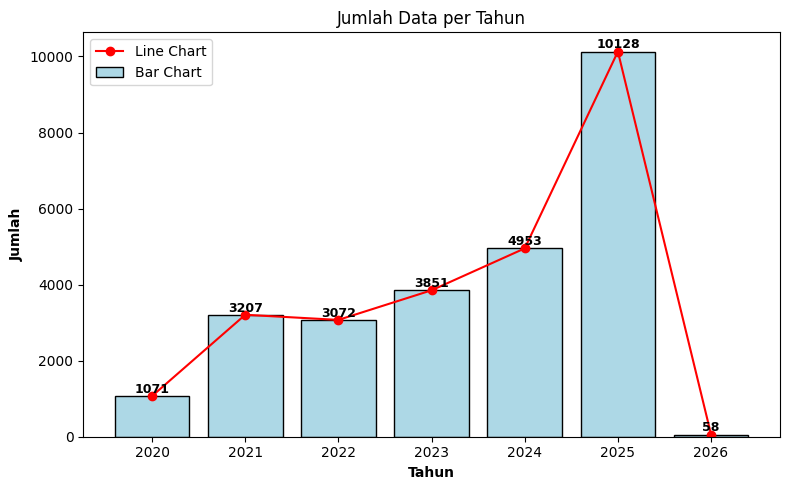

In [8]:
dataset['year'] = pd.to_datetime(dataset['date'], dayfirst=True).dt.year
year_counts = dataset['year'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(year_counts.index.astype(str), year_counts.values, color='lightblue', edgecolor='black', label='Bar Chart')
plt.plot(year_counts.index.astype(str), year_counts.values, color='Red', marker='o', label='Line Chart')
plt.title('Jumlah Data per Tahun')
plt.xlabel('Tahun', fontweight='bold')
plt.ylabel('Jumlah', fontweight='bold')

for i, val in enumerate(year_counts.values):
    plt.text(i, val + 3, str(val), ha='center', va='bottom', fontsize=9,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

CEK MISSING VALUE

In [9]:
missing = dataset.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nTidak ada data kosong.")
else:
    print(f"\nDitemukan total {missing.sum()} data kosong.")
    print("Detail posisi data yang kosong:")

    missing_positions = dataset[dataset.isnull().any(axis=1)]

    for idx, row in missing_positions.iterrows():
        cols_missing = row[row.isnull()].index.tolist()
        print(f"  • Baris ke-{idx}: kolom {cols_missing}")

video_id      0
author        0
comment       0
like_count    0
date          0
topic         0
year          0
dtype: int64

Tidak ada data kosong.


In [10]:
dataset['video_id'].unique()

array(['JTEhv7JCRF0', 'GzdFV_r-SHM', 'JL2VZdA9wuc', 'Xrbn47ZiFYw',
       'M0KYwjW-22c', 'bOsToXOFK4A', '_lAVXCvou78', 'pO43PBserhU',
       'Z3QfdLBjRWk', '28Eo_Xm8LYg', 'UfbQxFXre5Q', 'inF984LZKa0',
       'TCRV_d27iG0', '-YlHpqcgOow', 'QQM9BKY0_K8', '4CTYII_qHCQ',
       'kS16kRKYJGg', 'CKlWtn_c7Es', '59vXGu65IS4', 'AQLcjhHQBC0',
       'i86gVDwhNzg', 'MGpF_mdUVTg', 'e0SHDMs4bDk', '_99fDKfRq50',
       'YxYvJhEqC98', '3MeyTr2kdBg', '5Fv2tGv9_Vo', 'vvcBT2Fg5IQ',
       'ucfHy84xvec', 'iArT8RhBxzY', 'ypbdbIGDYGw', 'G1MjF639DrY',
       '1NnDgJzBAq4', 'mLdvwruqEpo', 'DcG3sqwpSa0', 'GO6PuKMedeM',
       '9zyK_C4g4qU', '-GyJN1tr9RM', 'y5B5sxJYEOI', 'zOKZCuwjWi8'],
      dtype=object)

PREPROCESSING DATA

##### _Cleaning & Case Folding_

In [11]:
df = dataset
duplikat = df.duplicated()
jumlah_duplikat = duplikat.sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")

baris_duplikat = df[df.duplicated()]
print("Baris duplikat:")
baris_duplikat

Jumlah baris duplikat: 20
Baris duplikat:


,video_id,author,comment,like_count,date,topic,year
317,JTEhv7JCRF0,@iingfatmawati3471,Bapa posisi di celegon KLO di celegon saya pe...,31,2025-05-21T08:24:56Z,pengendalian hama,2025
1880,GzdFV_r-SHM,@hakhidup5054,Ini adalah konten yang sangat bagus dan mengin...,156,2024-02-03T15:46:29Z,pengendalian hama,2024
3444,M0KYwjW-22c,@DUNIAIMAJINASIANAK811,Kita satu tujuan bang..dan Info sangat bermanf...,67,2024-01-18T08:46:41Z,pengendalian hama,2024
3909,bOsToXOFK4A,@PenyuluhPertanianLapangan,Absen dulu yuk.!!!,68,2025-04-25T11:31:22Z,pengendalian hama,2025
4884,Z3QfdLBjRWk,@PenyuluhPertanianLapangan,"Jika ada pertanyaan, silakan langsung komen aj...",38,2020-08-23T12:06:28Z,Pemupukan,2020
6188,28Eo_Xm8LYg,@kebunindratarigan,Ilmunya selalu keren dan didukung bukti ilmiah...,193,2021-03-26T13:57:11Z,Pemupukan,2021
6650,UfbQxFXre5Q,@PenyuluhPertanianLapangan,"Coba tebak tebakan nih, menurut anda, apa peny...",15,2022-01-14T08:13:54Z,Pemupukan,2022
6960,inF984LZKa0,@kasmiatikasmiati2320,Maap takaran tutup kah \nUntuk 1liter air brap...,0,2025-11-23T12:41:19Z,Pemupukan,2025
7698,inF984LZKa0,@rahmahizbin2529,Maaf bang bru koment tapi sllu mengikuti chane...,470,2025-10-16T01:01:51Z,Pemupukan,2025
8673,TCRV_d27iG0,@PenyuluhPertanianLapangan,Siapa aja nih yang hadir dan dari daerah mana ...,98,2020-10-14T12:01:36Z,Pemupukan,2020


In [12]:
duplikat = df.duplicated(subset='comment')
jumlah_duplikat = duplikat.sum()
print(f"Jumlah baris komentar duplikat: {jumlah_duplikat}")

jumlah_per_review = df['comment'].value_counts()
duplikat_review = jumlah_per_review[jumlah_per_review > 1]
tabel_duplikat = duplikat_review.reset_index()
tabel_duplikat.columns = ['comment', 'Jumlah Kemunculan']

print("\nKomentar yang duplikat beserta jumlah kemunculannya:")
tabel_duplikat

Jumlah baris komentar duplikat: 694

Komentar yang duplikat beserta jumlah kemunculannya:


,comment,Jumlah Kemunculan
0,Mantap,68
1,Keren,44
2,❤,25
3,❤❤❤,18
4,👍,17
...,...,...
282,Thank you,2
283,Pret,2
284,Ayok mulai kita olah semua limbah organik di r...,2
285,👍💪,2


In [13]:
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F700-\U0001F77F"  # alchemical symbols
        u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
        u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
        u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
        u"\U0001FA00-\U0001FA6F"  # Chess Symbols
        u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
        u"\U00002702-\U000027B0"  # Dingbats
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)
def clean_data(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)  # Menghapus semua tag HTML
    text = re.sub(r'&\w+;', ' ', text)  # Menghapus entitas HTML seperti &space
    text = re.sub(r"['\n&\\#]", "", text)  # Menghapus simbol seperti ' \n & #
    text = re.sub(r'(\w)(space)', r'\1 \2', text, flags=re.IGNORECASE)  # Mengubah 'space' menjadi spasi
    text = re.sub(r'[^a-zA-Z ]', ' ', text)  # Menghapus karakter selain huruf dan spasi
    text = re.sub(r'\s+', ' ', text).strip()  # Menghapus spasi berlebih
    return text.lower()

df['comment'] = df['comment'].apply(remove_emojis)
df['comment'] = df['comment'].astype(str)
df['comment'] = df['comment'].apply(clean_data)
df = df[df['comment'] != '']

In [14]:
df.to_csv("data/Cleaning.csv", index=False, encoding="utf-8-sig")
df.info()

create_table_query = """
CREATE TABLE IF NOT EXISTS Cleaning (
    id SERIAL PRIMARY KEY,
    video_id VARCHAR,
    author VARCHAR,
    comment VARCHAR,
    like_count INTEGER,
    date VARCHAR,
    topic VARCHAR,
    year INTEGER
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()

df.to_sql("cleaning", engine, if_exists="append", index=False)
print("Data berhasil disimpan ke PostgreSQL!")
df

<class 'pandas.core.frame.DataFrame'>
Index: 26070 entries, 0 to 26339
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   video_id    26070 non-null  object
 1   author      26070 non-null  object
 2   comment     26070 non-null  object
 3   like_count  26070 non-null  int64 
 4   date        26070 non-null  object
 5   topic       26070 non-null  object
 6   year        26070 non-null  int32 
dtypes: int32(1), int64(1), object(5)
memory usage: 1.5+ MB
Data berhasil disimpan ke PostgreSQL!


,video_id,author,comment,like_count,date,topic,year
0,JTEhv7JCRF0,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21T08:24:56Z,pengendalian hama,2025
1,JTEhv7JCRF0,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04T16:35:57Z,pengendalian hama,2026
2,JTEhv7JCRF0,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03T13:47:10Z,pengendalian hama,2026
3,JTEhv7JCRF0,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama,2026
4,JTEhv7JCRF0,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31T23:50:11Z,pengendalian hama,2025
...,...,...,...,...,...,...,...
26335,zOKZCuwjWi8,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14T00:31:46Z,Hidroponik,2025
26336,zOKZCuwjWi8,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13T16:10:54Z,Hidroponik,2025
26337,zOKZCuwjWi8,@fashionshow2380,assalamualaikum bang,1,2025-04-13T16:09:49Z,Hidroponik,2025
26338,zOKZCuwjWi8,@TisaDamayanti-x3u,mksh ya,1,2025-04-13T14:38:14Z,Hidroponik,2025


##### _Normalization_

In [15]:
kamus_data = pd.read_excel("kamuskatabaku.xlsx")

kamus_data["tidak_baku"] = kamus_data["tidak_baku"].astype(str).str.lower().str.strip()
kamus_data["kata_baku"] = kamus_data["kata_baku"].astype(str).str.lower().str.strip()

duplikat = kamus_data.duplicated()
jumlah_duplikat = duplikat.sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")

duplikat_group = (
    kamus_data
    .groupby(['tidak_baku', 'kata_baku'])
    .size()
    .reset_index(name='jumlah_kemunculan')
)

duplikat_lebih_dari_satu = duplikat_group[
    duplikat_group['jumlah_kemunculan'] > 1
]

kamus_data = kamus_data.drop_duplicates()

kamus_data.to_csv('data/kamuskatabaku.xlxs', index=False)
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS kamuskatabaku;"))
    conn.commit()

kamus_data.to_sql(
    "kamuskatabaku",
    engine,
    if_exists="replace", 
    index=False
)

print("Kamus berhasil disimpan ke PostgreSQL!")

Jumlah baris duplikat: 10743
Kamus berhasil disimpan ke PostgreSQL!


In [16]:
kamus_data = kamus_data.drop_duplicates(subset=['tidak_baku', 'kata_baku'])
duplikat = kamus_data.duplicated()
jumlah_duplikat = duplikat.sum()
print(f"Jumlah baris duplikat setelah dihapus: {jumlah_duplikat}")

kamus_data.to_csv('data/kamuskata.csv', index=False)
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS kamuskata;"))
    conn.commit()

kamus_data.to_sql(
    "kamuskata",
    engine,
    if_exists="replace",
    index=False
)

print("Data kamus berhasil disimpan ke PostgreSQL!")

Jumlah baris duplikat setelah dihapus: 0
Data kamus berhasil disimpan ke PostgreSQL!


In [17]:
df = df.copy()

pattern = r'\b(' + '|'.join(re.escape(k) for k in kamus_data.keys()) + r')\b'
def normalisasi_batch(teks):
    return teks.str.replace(pattern, lambda m: kamus_data[m.group(0)], regex=True)

df['normalization'] = normalisasi_batch(df['comment'])
df.to_csv('data/Normalization.csv', index=False, encoding='utf-8-sig')

create_table_query = """
CREATE TABLE IF NOT EXISTS normalization (
    id SERIAL PRIMARY KEY,
    video_id VARCHAR,
    author VARCHAR,
    comment VARCHAR,
    like_count INTEGER,
    date VARCHAR,
    topic VARCHAR,
    year INTEGER,
    normalization VARCHAR
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()

df.to_sql("normalization", engine, if_exists="append", index=False)
print("Data berhasil disimpan ke PostgreSQL!")
df

Data berhasil disimpan ke PostgreSQL!


,video_id,author,comment,like_count,date,topic,year,normalization
0,JTEhv7JCRF0,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21T08:24:56Z,pengendalian hama,2025,bapa posisi di celegon klo di celegon saya pen...
1,JTEhv7JCRF0,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04T16:35:57Z,pengendalian hama,2026,itu bisa di campur dengan pupuk ultradap ndak
2,JTEhv7JCRF0,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03T13:47:10Z,pengendalian hama,2026,terima kasih pak atas pembekalan ilmunya semog...
3,JTEhv7JCRF0,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama,2026,untuk dosis nya gimana pak
4,JTEhv7JCRF0,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31T23:50:11Z,pengendalian hama,2025,maaf saya dari pandeglang alamat bapak di mana...
...,...,...,...,...,...,...,...,...
26335,zOKZCuwjWi8,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14T00:31:46Z,Hidroponik,2025,pengendelaian hama menggunakan pestisida apa ka
26336,zOKZCuwjWi8,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13T16:10:54Z,Hidroponik,2025,blh apa enga bang saya minta cara taneman
26337,zOKZCuwjWi8,@fashionshow2380,assalamualaikum bang,1,2025-04-13T16:09:49Z,Hidroponik,2025,assalamualaikum bang
26338,zOKZCuwjWi8,@TisaDamayanti-x3u,mksh ya,1,2025-04-13T14:38:14Z,Hidroponik,2025,mksh ya


##### _Tokenizing_

In [18]:
def tokenize_text(text):
    return text.split()
def tokens_to_string(tokensisasi):
    return ', '.join(tokensisasi)

df['tokenizing'] = df['normalization'].apply(tokenize_text)
df['tokenizing'] = df['tokenizing'].apply(tokens_to_string)
df.to_csv('data/Tokenizing.csv', index=False)

create_table_query = """
CREATE TABLE IF NOT EXISTS tokenizing (
    id SERIAL PRIMARY KEY,
    video_id VARCHAR,
    author VARCHAR,
    comment VARCHAR,
    like_count INTEGER,
    date VARCHAR,
    topic VARCHAR,
    year INTEGER,
    normalization VARCHAR,
    tokenizing VARCHAR
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()

df.to_sql("tokenizing", engine, if_exists="append", index=False)
print("Data berhasil disimpan ke PostgreSQL!")
df

Data berhasil disimpan ke PostgreSQL!


,video_id,author,comment,like_count,date,topic,year,normalization,tokenizing
0,JTEhv7JCRF0,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21T08:24:56Z,pengendalian hama,2025,bapa posisi di celegon klo di celegon saya pen...,"bapa, posisi, di, celegon, klo, di, celegon, s..."
1,JTEhv7JCRF0,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04T16:35:57Z,pengendalian hama,2026,itu bisa di campur dengan pupuk ultradap ndak,"itu, bisa, di, campur, dengan, pupuk, ultradap..."
2,JTEhv7JCRF0,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03T13:47:10Z,pengendalian hama,2026,terima kasih pak atas pembekalan ilmunya semog...,"terima, kasih, pak, atas, pembekalan, ilmunya,..."
3,JTEhv7JCRF0,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama,2026,untuk dosis nya gimana pak,"untuk, dosis, nya, gimana, pak"
4,JTEhv7JCRF0,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31T23:50:11Z,pengendalian hama,2025,maaf saya dari pandeglang alamat bapak di mana...,"maaf, saya, dari, pandeglang, alamat, bapak, d..."
...,...,...,...,...,...,...,...,...,...
26335,zOKZCuwjWi8,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14T00:31:46Z,Hidroponik,2025,pengendelaian hama menggunakan pestisida apa ka,"pengendelaian, hama, menggunakan, pestisida, a..."
26336,zOKZCuwjWi8,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13T16:10:54Z,Hidroponik,2025,blh apa enga bang saya minta cara taneman,"blh, apa, enga, bang, saya, minta, cara, taneman"
26337,zOKZCuwjWi8,@fashionshow2380,assalamualaikum bang,1,2025-04-13T16:09:49Z,Hidroponik,2025,assalamualaikum bang,"assalamualaikum, bang"
26338,zOKZCuwjWi8,@TisaDamayanti-x3u,mksh ya,1,2025-04-13T14:38:14Z,Hidroponik,2025,mksh ya,"mksh, ya"


##### _Stopword Removal_

In [19]:
nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(text):
    tokens = text.split(', ')
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    return ', '.join(filtered_tokens)

df = pd.read_csv('data/Tokenizing.csv')
df['stopword'] = df['tokenizing'].apply(remove_stopwords)
df.to_csv('data/Stopword.csv', index=False)

create_table_query = """
CREATE TABLE IF NOT EXISTS stopword (
    id SERIAL PRIMARY KEY,
    video_id VARCHAR,
    author VARCHAR,
    comment VARCHAR,
    like_count INTEGER,
    date VARCHAR,
    topic VARCHAR,
    year INTEGER,
    normalization VARCHAR,
    tokenizing VARCHAR,
    stopword VARCHAR
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()

df.to_sql("stopword", engine, if_exists="append", index=False)
print("Data berhasil disimpan ke PostgreSQL!")
df

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asuss\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Data berhasil disimpan ke PostgreSQL!


,video_id,author,comment,like_count,date,topic,year,normalization,tokenizing,stopword
0,JTEhv7JCRF0,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21T08:24:56Z,pengendalian hama,2025,bapa posisi di celegon klo di celegon saya pen...,"bapa, posisi, di, celegon, klo, di, celegon, s...","bapa, posisi, celegon, klo, celegon, pengin, s..."
1,JTEhv7JCRF0,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04T16:35:57Z,pengendalian hama,2026,itu bisa di campur dengan pupuk ultradap ndak,"itu, bisa, di, campur, dengan, pupuk, ultradap...","campur, pupuk, ultradap, ndak"
2,JTEhv7JCRF0,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03T13:47:10Z,pengendalian hama,2026,terima kasih pak atas pembekalan ilmunya semog...,"terima, kasih, pak, atas, pembekalan, ilmunya,...","terima, kasih, pembekalan, ilmunya, semoga, ke..."
3,JTEhv7JCRF0,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama,2026,untuk dosis nya gimana pak,"untuk, dosis, nya, gimana, pak","dosis, nya, gimana"
4,JTEhv7JCRF0,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31T23:50:11Z,pengendalian hama,2025,maaf saya dari pandeglang alamat bapak di mana...,"maaf, saya, dari, pandeglang, alamat, bapak, d...","maaf, pandeglang, alamat, sy, belajar, tani, c..."
...,...,...,...,...,...,...,...,...,...,...
26065,zOKZCuwjWi8,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14T00:31:46Z,Hidroponik,2025,pengendelaian hama menggunakan pestisida apa ka,"pengendelaian, hama, menggunakan, pestisida, a...","pengendelaian, hama, pestisida, ka"
26066,zOKZCuwjWi8,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13T16:10:54Z,Hidroponik,2025,blh apa enga bang saya minta cara taneman,"blh, apa, enga, bang, saya, minta, cara, taneman","blh, enga, bang, taneman"
26067,zOKZCuwjWi8,@fashionshow2380,assalamualaikum bang,1,2025-04-13T16:09:49Z,Hidroponik,2025,assalamualaikum bang,"assalamualaikum, bang","assalamualaikum, bang"
26068,zOKZCuwjWi8,@TisaDamayanti-x3u,mksh ya,1,2025-04-13T14:38:14Z,Hidroponik,2025,mksh ya,"mksh, ya","mksh, ya"


##### _Stemming_

In [20]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def split_combined_words(text):
    text = re.sub(r'\bng([a-z]+)', r'\1', text)
    text = re.sub(r'\bke([a-z]+)', r'\1', text)
    text = re.sub(r'\bdi([a-z]+)', r'\1', text)
    text = re.sub(r'\bmeng([a-z]+)', r'\1', text)
    text = re.sub(r'nya\b', '', text)
    return text

def stem_text_with_split(text):
    text = split_combined_words(text)
    words = [word.strip() for word in text.split(',')]
    stemmed_words = [stemmer.stem(word) for word in words]
    return ', '.join(stemmed_words)

df['stemming'] = df['stopword'].apply(stem_text_with_split)
df.to_csv('data/Stemming.csv', index=False, encoding='utf-8')

create_table_query = """
CREATE TABLE IF NOT EXISTS stemming (
    id SERIAL PRIMARY KEY,
    video_id VARCHAR,
    author VARCHAR,
    comment VARCHAR,
    like_count INTEGER,
    date VARCHAR,
    topic VARCHAR,
    year INTEGER,
    normalization VARCHAR,
    tokenizing VARCHAR,
    stopword VARCHAR,
    stemming VARCHAR
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()

df.to_sql("stemming", engine, if_exists="append", index=False)
print("Data berhasil disimpan ke PostgreSQL!")
df

Data berhasil disimpan ke PostgreSQL!


,video_id,author,comment,like_count,date,topic,year,normalization,tokenizing,stopword,stemming
0,JTEhv7JCRF0,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21T08:24:56Z,pengendalian hama,2025,bapa posisi di celegon klo di celegon saya pen...,"bapa, posisi, di, celegon, klo, di, celegon, s...","bapa, posisi, celegon, klo, celegon, pengin, s...","bapa, posisi, celegon, klo, celegon, pengin, s..."
1,JTEhv7JCRF0,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04T16:35:57Z,pengendalian hama,2026,itu bisa di campur dengan pupuk ultradap ndak,"itu, bisa, di, campur, dengan, pupuk, ultradap...","campur, pupuk, ultradap, ndak","campur, pupuk, ultradap, ndak"
2,JTEhv7JCRF0,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03T13:47:10Z,pengendalian hama,2026,terima kasih pak atas pembekalan ilmunya semog...,"terima, kasih, pak, atas, pembekalan, ilmunya,...","terima, kasih, pembekalan, ilmunya, semoga, ke...","terima, kasih, bekal, ilmu, moga, luarga, sehat"
3,JTEhv7JCRF0,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama,2026,untuk dosis nya gimana pak,"untuk, dosis, nya, gimana, pak","dosis, nya, gimana","dosis, , gimana"
4,JTEhv7JCRF0,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31T23:50:11Z,pengendalian hama,2025,maaf saya dari pandeglang alamat bapak di mana...,"maaf, saya, dari, pandeglang, alamat, bapak, d...","maaf, pandeglang, alamat, sy, belajar, tani, c...","maaf, pandeglang, alamat, sy, ajar, tani, cabai"
...,...,...,...,...,...,...,...,...,...,...,...
26065,zOKZCuwjWi8,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14T00:31:46Z,Hidroponik,2025,pengendelaian hama menggunakan pestisida apa ka,"pengendelaian, hama, menggunakan, pestisida, a...","pengendelaian, hama, pestisida, ka","pengendelaian, hama, pestisida, ka"
26066,zOKZCuwjWi8,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13T16:10:54Z,Hidroponik,2025,blh apa enga bang saya minta cara taneman,"blh, apa, enga, bang, saya, minta, cara, taneman","blh, enga, bang, taneman","blh, enga, bang, taneman"
26067,zOKZCuwjWi8,@fashionshow2380,assalamualaikum bang,1,2025-04-13T16:09:49Z,Hidroponik,2025,assalamualaikum bang,"assalamualaikum, bang","assalamualaikum, bang","assalamualaikum, bang"
26068,zOKZCuwjWi8,@TisaDamayanti-x3u,mksh ya,1,2025-04-13T14:38:14Z,Hidroponik,2025,mksh ya,"mksh, ya","mksh, ya","mksh, ya"


EKSPLORASI DATA SETELAH PREPROCESSING

In [ ]:
df['year'] = pd.to_datetime(df['date'], dayfirst=True).dt.year
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(year_counts.index.astype(str), year_counts.values, color='lightblue', edgecolor='black', label='Bar Chart')
plt.plot(year_counts.index.astype(str), year_counts.values, color='Red', marker='o', label='Line Chart')
plt.title('Jumlah Data per Tahun')
plt.xlabel('Tahun', fontweight='bold')
plt.ylabel('Jumlah', fontweight='bold')

for i, val in enumerate(year_counts.values):
    plt.text(i, val + 3, str(val), ha='center', va='bottom', fontsize=9,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df_2025 = df[df['date'].dt.year == 2025]

month_counts = (
    df_2025['date']
    .dt.month
    .value_counts()
    .sort_index()
    .reindex(range(1, 13), fill_value=0)
)

month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(10,5))

bars = plt.bar(
    month_labels,
    month_counts.values,
    color='lightblue',
    edgecolor='black',
    label='Bar Chart'
)

plt.plot(
    month_labels,
    month_counts.values,
    color='red',
    marker='o',
    linewidth=2,
    label='Line Chart'
)

plt.title('Jumlah Data Tahun 2025')
plt.xlabel('Bulan', fontweight='bold')
plt.ylabel('Jumlah', fontweight='bold')

for i, val in enumerate(month_counts.values):
    plt.text(
        i,
        val + 2,
        str(val),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.legend()
plt.tight_layout()
plt.show()

PEMETAAN PERTANIAN

##### _keywords problem_

In [21]:
# KATEGORI_MAPPING = {
#     "pengendalian hama": [
#         {
#             "label": "risiko pestisida kesehatan",
#             "keywords": [
#                 "pestisida", "racun", "bahaya", "residu", 
#                 "kesehatan", "keracunan", "iritasi", "efek samping",
#                 "kontaminasi", "paparan", "aman", "tidak aman", "berbahaya", 
#                 "beracun", "zat kimia", "bikin pusing", "sesak", "mual", "bahaya buat anak", 
#                 "merusak lingkungan", "kapok", "trauma","meracuni", "tidak sehat", "ngeri-ngeri"
#             ]
#         },
#         {
#             "label": "efektivitas pengendalian hama",
#             "keywords": [
#                 "hama", "busuk", "ulat", "wereng", "tikus", "serangga", 
#                 "ampuh", "mempan", "tidak mempan", "efektif", "gagal", 
#                 "berhasil", "hilang", "mati", "kebal", "masih ada",
#                 "berkurang", "percuma", "ngaruh", "masih banyak", "sia sia"
#             ]
#         },
#         {
#             "label": "kompatibilitas pestisida",
#             "keywords": [
#                 "dosis", "takaran", "campur", "mix", "dicampur", "kombinasi", 
#                 "insektisida", "fungisida", "herbisida", "reaksi", "kompatibel", 
#                 "tidak cocok", "endapan", "larut", "salah campur", "rusak"
#             ]
#         },
#         {
#             "label": "alternatif pengendalian alami",
#             "keywords": [
#                 "alami", "obat", "nabati", "organik", "tradisional", "daun mimba", 
#                 "serai", "bawang putih", "alternatif", "tidak sekuat kimia", "ribet", 
#                 "ramuan", "fermentasi", "eco", "hayati", "musuh alami", "tanpa kimia"
#             ]
#         }
#     ],

#     "pemupukan": [
#         {
#             "label": "dosis dan waktu pupuk",
#             "keywords": [
#                 "pupuk", "dosis", "takaran", "berapa", "waktu", "jadwal", "kebanyakan",
#                 "umur tanaman", "fase", "awal tanam", "kelebihan", "kurang",
#                 "susulan", "terlalu banyak", "kurang", "asal tabur", "salah waktu"
#             ]
#         },
#         {
#             "label": "konflik pupuk kimia organik",
#             "keywords": [
#                 "kimia", "organik", "npk", "urea", "phonska", "za", "pupuk pabrik",
#                 "pupuk kandang", "kompos", "merusak tanah", "ketergantungan", 
#                 "tidak alami", "alami vs kimia", "perbandingan"
#             ]
#         },
#         {
#             "label": "dampak pupuk ke tanaman",
#             "keywords": [
#                 "layu", "kuning", "subur", "mati", "parah", "gosong", "terbakar", 
#                 "busuk", "mengecil", "kecil", "tumbuh", "kerdil", "segar",
#                 "habis", "cacat", "overdosis"
#             ]
#         },
#         {
#             "label": "efisiensi penggunaan pupuk",
#             "keywords": [
#                 "irit", "efisien", "hemat", "boros", "murah", "mahal", "terjangkau",
#                 "optimal", "maksimal", "buang-buang", "tepat guna", "rugi",
#                 "penghematan", "biaya pupuk"
#             ]
#         }
#     ],

#     "irigasi": [
#         {
#             "label": "efisiensi air irigasi",
#             "keywords": [
#                 "air", "boros", "hemat", "efisiensi", "irigasi","cukup", "kurang", 
#                 "kelebihan", "pengairan", "siraman", "kurang air", "melimpah",
#                 "air terbuang", "kekeringan"
#             ]
#         },
#         {
#             "label": "biaya infrastruktur irigasi",
#             "keywords": [
#                 "biaya", "pompa", "listrik", "pipa", "terjangkau", "murah",
#                 "instalasi", "perawatan", "mahal", "modal", "ongkos", "solar",
#                 "biaya  tinggi"            
#             ]
#         },
#         {
#             "label": "keandalan sistem irigasi",
#             "keywords": [
#                 "bocor", "macet", "jalan", "rusak", "lancar", "rewel", "aman",
#                 "tidak lancar", "tersumbat", "berfungsi", "mati", "normal", "stabil"
#             ]
#         },
#         {
#             "label": "teknologi irigasi modern",
#             "keywords": [
#                 "drip", "tetes", "otomatis", "sensor", "teknologi", "canggih",
#                 "sprinkler", "timer", "mudah", "praktis", "ringan", "smart farming", 
#                 "digital", "kontrol jarak jauh"
#             ]
#         }
#     ],

#     "budidaya organik": [
#         {
#             "label": "harga produk organik",
#             "keywords": [
#                 "mahal", "harga", "murah", "pasar", "selisih harga", "nilai jual", 
#                 "ekonomis", "terjangkau", "kompetitif", "tidak sebanding",
#                 "worth it", "overpriced" 
#             ]
#         },
#         {
#             "label": "hasil panen organik",
#             "keywords": [
#                 "panen", "hasil", "premium", "produksi", "melimpah", "sedikit",
#                 "kualitas", "ukuran", "fresh", "terjamin", "dicari", "bagus", "tanaman sehat",
#                 "berat", "jumlah", "kuantitas", "segar"
#             ]
#         },
#         {
#             "label": "kepercayaan produk organik",
#             "keywords": [
#                 "asli", "organik", "klaim", "label", "sertifikat", "percaya",
#                 "palsu", "diragukan", "bohong", "ngibul", "terpercaya", 
#                 "jaminan", "legal"
#             ]
#         },
#         {
#             "label": "minat konsumen organik",
#             "keywords": [
#                 "minat", "suka", "pilih", "konsumsi", "memadai", "lahan", "rawat",
#                 "tren", "gaya hidup", "ribet", "repot", "sehat", "kesadaran", "permintaan"
#             ]
#         }
#     ],

#     "hidroponik": [
#         {
#             "label": "biaya awal hidroponik",
#             "keywords": [
#                 "modal", "biaya", "mahal", "murah", "overprice", "harga",
#                 "investasi", "alat", "instalasi", "pipa", "pompa"
#             ]
#         },
#         {
#             "label": "kompleksitas perawatan",
#             "keywords": [
#                 "ph", "nutrisi", "ribet", "rawat", "kontrol", "cek rutin", "sejuk",
#                 "sulit", "mudah", "perawatan harian", "rewel", "monitoring", "solusi",
#                 "susah", "waktu luang", "praktis", "takaran", "tanam", "hidup", "air"
#                 "bibit", "benih", "metode", "mix"
#             ]
#         },
#         {
#             "label": "keuntungan hidroponik",
#             "keywords": [
#                 "untung", "hasil", "layak", "mudah", "cepat panen", "bersih",
#                 "hemat lahan", "efisien", "praktis", "menguntungkan", "produktif",
#                 "produksi stabil"
#             ]
#         },
#         {
#             "label": "minat hidroponik",
#             "keywords": [
#                 "coba", "tertarik", "mulai", "belajar", "suka", "pemula", "eksperimen", 
#                 "pengen", "ingin", "adopsi", "minat", "langkah awal"
#             ]
#         }
#     ]
# }

In [22]:
keywords=pd.read_csv("kategori_keywords.csv")

create_table_query = """
CREATE TABLE IF NOT EXISTS kategori_keywords (
    id SERIAL PRIMARY KEY,
    topic VARCHAR,
    label VARCHAR,
    keyword VARCHAR
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()

keywords.to_sql("kategori_keywords", engine, if_exists="append", index=False)
print("Data berhasil disimpan ke PostgreSQL!")
keywords

Data berhasil disimpan ke PostgreSQL!


,topic,label,keyword
0,Pengendalian Hama,risiko pestisida kesehatan,pestisida
1,Pengendalian Hama,risiko pestisida kesehatan,racun
2,Pengendalian Hama,risiko pestisida kesehatan,bahaya
3,Pengendalian Hama,risiko pestisida kesehatan,residu
4,Pengendalian Hama,risiko pestisida kesehatan,kesehatan
...,...,...,...
486,hidroponik,minat hidroponik,pengen belajar
487,hidroponik,minat hidroponik,mau mulai
488,hidroponik,minat hidroponik,penasaran hidroponik
489,hidroponik,minat hidroponik,tertarik sistem ini


##### _Pemetaan komentar_

In [23]:
df_comments = pd.read_sql("SELECT * FROM stemming ORDER BY id", engine)
df_keywords = pd.read_sql("SELECT topic, label, keyword FROM kategori_keywords ORDER BY id", engine)

print("Total keyword:", len(df_keywords))

df_comments["comment"] = df_comments["comment"].astype(str).str.lower()
df_comments["topic"] = df_comments["topic"].astype(str).str.lower().str.strip()
df_keywords["topic"] = df_keywords["topic"].astype(str).str.lower().str.strip()
df_keywords["keyword"] = df_keywords["keyword"].astype(str).str.lower().str.strip()
df_keywords["label"] = df_keywords["label"].astype(str).str.lower().str.strip()

category_mapping = {}

for _, row in df_keywords.iterrows():
    topic = row["topic"]
    label = row["label"]
    keyword = row["keyword"]

    category_mapping.setdefault(topic, {})
    category_mapping[topic].setdefault(label, [])
    category_mapping[topic][label].append(keyword)

print("Mapping berhasil dibuat.")
print("Total komentar:", len(df_comments))

def assign_category(row):
    topic = row["topic"]
    text = row["comment"]
    tokens = text.split()
    labels = []

    if topic in category_mapping:
        for label, keywords in category_mapping[topic].items():
            for kw in keywords:
                if " " in kw:
                    if kw in text:
                        labels.append(label)
                        break
                else:
                    if kw in tokens:
                        labels.append(label)
                        break

    if not labels:
        return "feedback penonton"

    labels = sorted(list(set(labels)))
    return ", ".join(labels)

df_comments["category"] = df_comments.apply(assign_category, axis=1)

print("Labeling selesai.")
print("Total row setelah labeling:", len(df_comments)) 

df_comments.to_sql(
    "mapping",
    engine,
    if_exists="replace",
    index=False
)

print("Data berhasil disimpan ke PostgreSQL!")

result = (
    df_comments["category"]
    .str.split(", ")
    .explode()
    .value_counts()
    .reset_index()
)

result.columns = ["category", "jumlah_komentar"]
result

Total keyword: 491
Mapping berhasil dibuat.
Total komentar: 26070
Labeling selesai.
Total row setelah labeling: 26070
Data berhasil disimpan ke PostgreSQL!


,category,jumlah_komentar
0,feedback penonton,18259
1,kompleksitas perawatan,2150
2,dosis dan waktu pupuk,1800
3,konflik pupuk kimia organik,1042
4,minat konsumen organik,645
5,efektivitas pengendalian hama,513
6,kepercayaan produk organik,381
7,minat hidroponik,341
8,hasil panen organik,338
9,biaya awal hidroponik,335


In [24]:
df = df_comments.copy()
df = df.drop(columns=["id"], errors="ignore")
df.to_csv("data/Mapping.csv", index=False, encoding="utf-8-sig")
df

,video_id,author,comment,like_count,date,topic,year,normalization,tokenizing,stopword,stemming,category
0,JTEhv7JCRF0,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21T08:24:56Z,pengendalian hama,2025,bapa posisi di celegon klo di celegon saya pen...,"bapa, posisi, di, celegon, klo, di, celegon, s...","bapa, posisi, celegon, klo, celegon, pengin, s...","bapa, posisi, celegon, klo, celegon, pengin, s...",feedback penonton
1,JTEhv7JCRF0,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04T16:35:57Z,pengendalian hama,2026,itu bisa di campur dengan pupuk ultradap ndak,"itu, bisa, di, campur, dengan, pupuk, ultradap...","campur, pupuk, ultradap, ndak","campur, pupuk, ultradap, ndak",kompatibilitas pestisida
2,JTEhv7JCRF0,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03T13:47:10Z,pengendalian hama,2026,terima kasih pak atas pembekalan ilmunya semog...,"terima, kasih, pak, atas, pembekalan, ilmunya,...","terima, kasih, pembekalan, ilmunya, semoga, ke...","terima, kasih, bekal, ilmu, moga, luarga, sehat",feedback penonton
3,JTEhv7JCRF0,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama,2026,untuk dosis nya gimana pak,"untuk, dosis, nya, gimana, pak","dosis, nya, gimana","dosis, , gimana",kompatibilitas pestisida
4,JTEhv7JCRF0,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31T23:50:11Z,pengendalian hama,2025,maaf saya dari pandeglang alamat bapak di mana...,"maaf, saya, dari, pandeglang, alamat, bapak, d...","maaf, pandeglang, alamat, sy, belajar, tani, c...","maaf, pandeglang, alamat, sy, ajar, tani, cabai",feedback penonton
...,...,...,...,...,...,...,...,...,...,...,...,...
26065,zOKZCuwjWi8,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14T00:31:46Z,hidroponik,2025,pengendelaian hama menggunakan pestisida apa ka,"pengendelaian, hama, menggunakan, pestisida, a...","pengendelaian, hama, pestisida, ka","pengendelaian, hama, pestisida, ka",feedback penonton
26066,zOKZCuwjWi8,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13T16:10:54Z,hidroponik,2025,blh apa enga bang saya minta cara taneman,"blh, apa, enga, bang, saya, minta, cara, taneman","blh, enga, bang, taneman","blh, enga, bang, taneman",feedback penonton
26067,zOKZCuwjWi8,@fashionshow2380,assalamualaikum bang,1,2025-04-13T16:09:49Z,hidroponik,2025,assalamualaikum bang,"assalamualaikum, bang","assalamualaikum, bang","assalamualaikum, bang",feedback penonton
26068,zOKZCuwjWi8,@TisaDamayanti-x3u,mksh ya,1,2025-04-13T14:38:14Z,hidroponik,2025,mksh ya,"mksh, ya","mksh, ya","mksh, ya",feedback penonton


In [25]:
df_video_category = df.copy()
df_video_category["category"] = df_video_category["category"].str.split(", ")

rekap_per_video = (
    df_video_category
    .groupby("video_id")["category"]
    .sum()
    .reset_index()
)

rekap_per_video["category"] = (
    rekap_per_video["category"]
    .apply(lambda x: ", ".join(sorted(set(x))))
)

rekap_per_video.to_csv("data/Rekap_category_video.csv", index=False, encoding="utf-8-sig")

print(f"Data berhasil disimpan ke CSV: Rekap_category_video.csv")

rekap_per_video.to_sql(
    "rekap_category_video",        
    engine,
    if_exists="replace",  
    index=False
)

print("Data berhasil disimpan ke PostgreSQL")
display(rekap_per_video)

Data berhasil disimpan ke CSV: Rekap_category_video.csv
Data berhasil disimpan ke PostgreSQL


,video_id,category
0,-GyJN1tr9RM,"biaya awal hidroponik, feedback penonton, keun..."
1,-YlHpqcgOow,"dampak pupuk ke tanaman, dosis dan waktu pupuk..."
2,1NnDgJzBAq4,"biaya awal hidroponik, feedback penonton, keun..."
3,28Eo_Xm8LYg,"dampak pupuk ke tanaman, dosis dan waktu pupuk..."
4,3MeyTr2kdBg,"feedback penonton, harga produk organik, hasil..."
5,4CTYII_qHCQ,"dampak pupuk ke tanaman, dosis dan waktu pupuk..."
6,59vXGu65IS4,"biaya infrastruktur irigasi, efisiensi air iri..."
7,5Fv2tGv9_Vo,"feedback penonton, harga produk organik, hasil..."
8,9zyK_C4g4qU,"biaya awal hidroponik, feedback penonton, keun..."
9,AQLcjhHQBC0,"biaya infrastruktur irigasi, efisiensi air iri..."


In [26]:
engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

output_dir = "csv_per_category"
os.makedirs(output_dir, exist_ok=True)

all_labels = (
    df["category"]
    .str.split(", ")
    .explode()
    .unique()
)

print("Total label unik:", len(all_labels))

for category in all_labels:
    df_category = df[
        df["category"].str.contains(category, regex=False)
    ]

    safe_category = category.replace(" ", "_").replace("-", "_").lower()
    
    cols_to_save = [
        'video_id', 'author', 'comment', 'like_count', 'date',
        'topic', 'year', 'normalization', 'tokenizing',
        'stopword', 'stemming', 'category'
    ]
    df_final = df_category[cols_to_save]

    file_path = os.path.join(output_dir, f"{safe_category}.csv")
    df_final.to_csv(file_path, index=False, encoding="utf-8-sig")

    df_final.to_sql(
        name=safe_category, 
        con=engine, 
        if_exists='replace', 
        index=False
    )

    print(f"Berhasil: {safe_category} | Lokal: OK | Database: OK | Baris: {len(df_category)}")

print("Semua file dan tabel database berhasil dibuat!")

Total label unik: 21
Berhasil: feedback_penonton | Lokal: OK | Database: OK | Baris: 18259
Berhasil: kompatibilitas_pestisida | Lokal: OK | Database: OK | Baris: 332
Berhasil: efektivitas_pengendalian_hama | Lokal: OK | Database: OK | Baris: 513
Berhasil: risiko_pestisida_kesehatan | Lokal: OK | Database: OK | Baris: 263
Berhasil: alternatif_pengendalian_alami | Lokal: OK | Database: OK | Baris: 71
Berhasil: dosis_dan_waktu_pupuk | Lokal: OK | Database: OK | Baris: 1800
Berhasil: efisiensi_penggunaan_pupuk | Lokal: OK | Database: OK | Baris: 136
Berhasil: dampak_pupuk_ke_tanaman | Lokal: OK | Database: OK | Baris: 316
Berhasil: konflik_pupuk_kimia_organik | Lokal: OK | Database: OK | Baris: 1042
Berhasil: biaya_infrastruktur_irigasi | Lokal: OK | Database: OK | Baris: 125
Berhasil: efisiensi_air_irigasi | Lokal: OK | Database: OK | Baris: 228
Berhasil: teknologi_irigasi_modern | Lokal: OK | Database: OK | Baris: 196
Berhasil: keandalan_sistem_irigasi | Lokal: OK | Database: OK | Baris:

ANALISIS SENTIMEN

##### _All File_

In [27]:
df_keywords = pd.read_csv("sentiment_keywords.csv")

create_table_query = """
CREATE TABLE IF NOT EXISTS sentiment_keywords (
    id SERIAL PRIMARY KEY,
    topic VARCHAR,
    sentiment VARCHAR,
    keyword VARCHAR
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()

keywords.to_sql("kategori_keywords", engine, if_exists="append", index=False)

topic_keywords = {}

for _, row in df_keywords.iterrows():
    topic = row["topic"]
    sentiment = row["sentiment"].lower()
    keyword = row["keyword"].lower()

    if topic not in topic_keywords:
        topic_keywords[topic] = {"positive": [], "negative": []}

    topic_keywords[topic][sentiment].append(keyword)

def detect_topic(text):
    text = text.lower()
    for topic, kws in topic_keywords.items():
        all_words = kws["positive"] + kws["negative"]
        if any(word in text for word in all_words):
            return topic
    return None

def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return None

    clean = re.sub(r"http\S+|www\S+|[^a-zA-Z\s]", " ", text)
    clean = re.sub(r"\s+", " ", clean).strip().lower()

    topic = detect_topic(clean)

    rule_sentiment = None

    if topic:
        pos_words = topic_keywords[topic]["positive"]
        neg_words = topic_keywords[topic]["negative"]

        if any(w in clean for w in pos_words):
            rule_sentiment = "Positif"
        elif any(w in clean for w in neg_words):
            rule_sentiment = "Negatif"

    polarity = TextBlob(clean).sentiment.polarity
    blob_sentiment = (
        "Positif" if polarity > 0.1
        else "Negatif" if polarity < -0.1
        else "Netral"
    )

    if rule_sentiment == blob_sentiment:
        return blob_sentiment

    if rule_sentiment and blob_sentiment != "Netral":
        return blob_sentiment

    if rule_sentiment and blob_sentiment == "Netral":
        return rule_sentiment

    return "Netral"

df = df.copy()
df["sentiment"] = df["comment"].apply(get_sentiment)

sentiment_counts = df["sentiment"].value_counts()

print("Jumlah komentar Positif:", sentiment_counts.get("Positif", 0))
print("Jumlah komentar Netral:", sentiment_counts.get("Netral", 0))
print("Jumlah komentar Negatif:", sentiment_counts.get("Negatif", 0))

df.to_csv("data/Sentiment.csv", index=False, encoding="utf-8-sig")
df.to_sql("sentiment", engine, if_exists="replace", index=False)
print("Data sentiment berhasil disimpan ke PostgreSQL!")
print("\nAnalisis sentimen selesai dan disimpan ke 'Sentiment.csv'")
df

Jumlah komentar Positif: 7669
Jumlah komentar Netral: 16901
Jumlah komentar Negatif: 1500
Data sentiment berhasil disimpan ke PostgreSQL!

Analisis sentimen selesai dan disimpan ke 'Sentiment.csv'


,video_id,author,comment,like_count,date,topic,year,normalization,tokenizing,stopword,stemming,category,sentiment
0,JTEhv7JCRF0,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21T08:24:56Z,pengendalian hama,2025,bapa posisi di celegon klo di celegon saya pen...,"bapa, posisi, di, celegon, klo, di, celegon, s...","bapa, posisi, celegon, klo, celegon, pengin, s...","bapa, posisi, celegon, klo, celegon, pengin, s...",feedback penonton,Netral
1,JTEhv7JCRF0,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04T16:35:57Z,pengendalian hama,2026,itu bisa di campur dengan pupuk ultradap ndak,"itu, bisa, di, campur, dengan, pupuk, ultradap...","campur, pupuk, ultradap, ndak","campur, pupuk, ultradap, ndak",kompatibilitas pestisida,Netral
2,JTEhv7JCRF0,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03T13:47:10Z,pengendalian hama,2026,terima kasih pak atas pembekalan ilmunya semog...,"terima, kasih, pak, atas, pembekalan, ilmunya,...","terima, kasih, pembekalan, ilmunya, semoga, ke...","terima, kasih, bekal, ilmu, moga, luarga, sehat",feedback penonton,Positif
3,JTEhv7JCRF0,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama,2026,untuk dosis nya gimana pak,"untuk, dosis, nya, gimana, pak","dosis, nya, gimana","dosis, , gimana",kompatibilitas pestisida,Netral
4,JTEhv7JCRF0,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31T23:50:11Z,pengendalian hama,2025,maaf saya dari pandeglang alamat bapak di mana...,"maaf, saya, dari, pandeglang, alamat, bapak, d...","maaf, pandeglang, alamat, sy, belajar, tani, c...","maaf, pandeglang, alamat, sy, ajar, tani, cabai",feedback penonton,Negatif
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26065,zOKZCuwjWi8,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14T00:31:46Z,hidroponik,2025,pengendelaian hama menggunakan pestisida apa ka,"pengendelaian, hama, menggunakan, pestisida, a...","pengendelaian, hama, pestisida, ka","pengendelaian, hama, pestisida, ka",feedback penonton,Negatif
26066,zOKZCuwjWi8,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13T16:10:54Z,hidroponik,2025,blh apa enga bang saya minta cara taneman,"blh, apa, enga, bang, saya, minta, cara, taneman","blh, enga, bang, taneman","blh, enga, bang, taneman",feedback penonton,Netral
26067,zOKZCuwjWi8,@fashionshow2380,assalamualaikum bang,1,2025-04-13T16:09:49Z,hidroponik,2025,assalamualaikum bang,"assalamualaikum, bang","assalamualaikum, bang","assalamualaikum, bang",feedback penonton,Netral
26068,zOKZCuwjWi8,@TisaDamayanti-x3u,mksh ya,1,2025-04-13T14:38:14Z,hidroponik,2025,mksh ya,"mksh, ya","mksh, ya","mksh, ya",feedback penonton,Netral


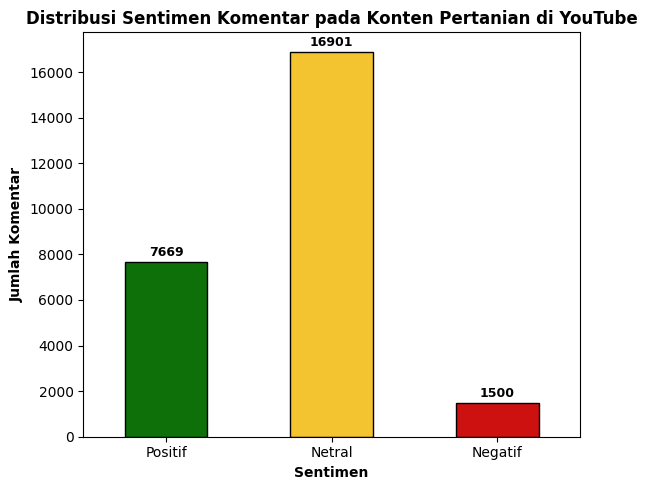

In [28]:
sentiment_order = ["Positif", "Netral", "Negatif"]
sentiment_counts = df["sentiment"].value_counts().reindex(sentiment_order, fill_value=0)


ax = sentiment_counts.plot(
    kind='bar',
    figsize=(6, 5),
    color=["#0D7009", "#F4C430", "#cd1111"],
    edgecolor='black'
)

plt.xlabel('Sentimen', fontweight='bold')
plt.ylabel('Jumlah Komentar', fontweight='bold')
plt.title('Distribusi Sentimen Komentar pada Konten Pertanian di YouTube', fontweight='bold')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='baseline',
        fontsize=9, color='black',
        xytext=(0, 4), textcoords='offset points',
        fontweight='bold'
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

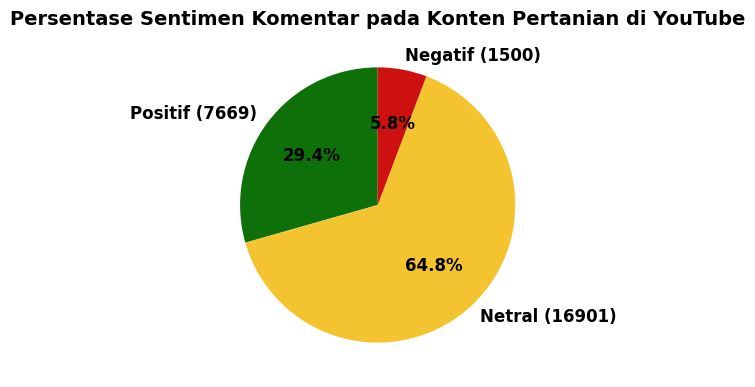

In [29]:
sentiment_percent = (sentiment_counts / sentiment_counts.sum()) * 100
colors = ["#0D7009", "#F4C430", "#cd1111"]

plt.figure(figsize=(5, 5))
plt.pie(
    sentiment_counts,
    labels=[
        f"{label} ({count})"
        for label, count, percent in zip(sentiment_counts.index, sentiment_counts, sentiment_percent)
    ],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title("Persentase Sentimen Komentar pada Konten Pertanian di YouTube", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

WORDCLOUD ALL

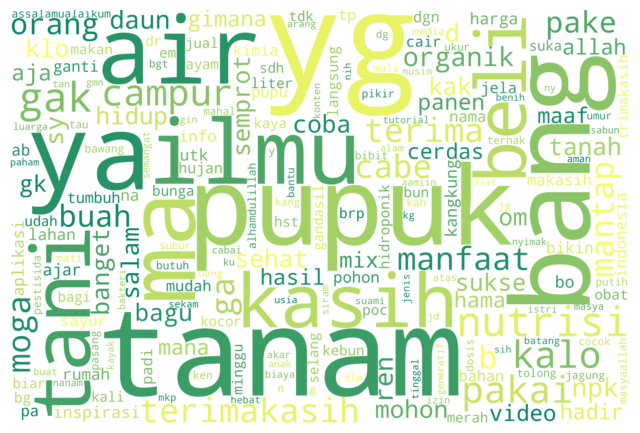

Gambar wordcloud_all berhasil disimpan ke database tabel 'app_assets'


In [30]:
def save_image_to_db(image_path, category_name):
    """Fungsi untuk menyimpan file gambar lokal ke PostgreSQL"""
    try:
        with open(image_path, "rb") as f:
            binary_data = f.read()
        
        table_name = "app_assets"
        
        df_img = pd.DataFrame([{
            'name': category_name,
            'image_data': binary_data,
            'file_type': 'png'
        }])
        
        df_img.to_sql(table_name, engine, if_exists='append', index=False)
        print(f"Gambar {category_name} berhasil disimpan ke database tabel '{table_name}'")
        
    except Exception as e:
        print(f"Gagal menyimpan gambar ke database: {e}")

def plot_cloud(wordcloud, filename="wordcloud_all.png", category="all"):
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show() 
    plt.close() 
    save_image_to_db(filename, f"wordcloud_{category}")

all_words = ' '.join([tweets for tweets in df['stemming']])
wordcloud = WordCloud(width=3000, height=2000, random_state=3, background_color='white',
                      colormap='summer', collocations=False, stopwords=STOPWORDS).generate(all_words)

plot_cloud(wordcloud, filename="wordcloud_all.png", category="all")

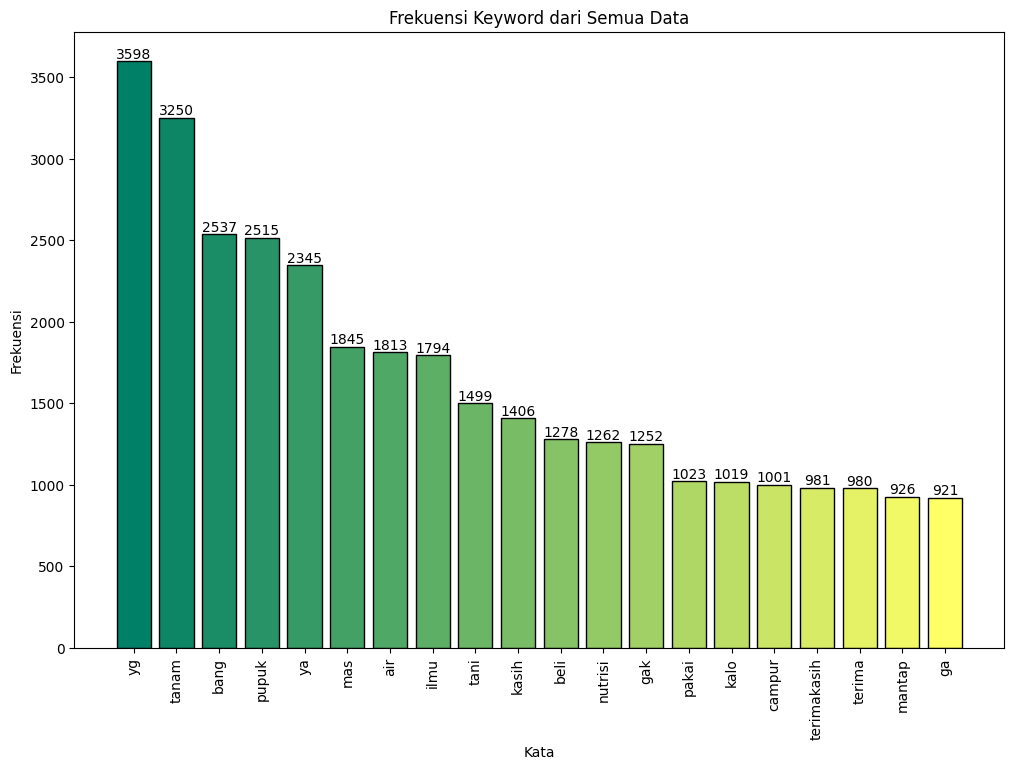

Gambar frekuensi_all berhasil disimpan ke database tabel 'app_assets'


In [31]:
def save_image_to_db(image_path, category_name):
    """Fungsi untuk menyimpan file gambar lokal ke PostgreSQL"""
    try:
        with open(image_path, "rb") as f:
            binary_data = f.read()
        
        table_name = "app_assets"
        
        df_img = pd.DataFrame([{
            'name': category_name,
            'image_data': binary_data,
            'file_type': 'png'
        }])
        
        df_img.to_sql(table_name, engine, if_exists='append', index=False)
        print(f"Gambar {category_name} berhasil disimpan ke database tabel '{table_name}'")
        
    except Exception as e:
        print(f"Gagal menyimpan gambar ke database: {e}")

text_data = ' '.join(df['stemming'])
vectorizer = CountVectorizer()
X = vectorizer.fit_transform([text_data])
word_freq = X.toarray().flatten()
words = vectorizer.get_feature_names_out()
word_freq_df = pd.DataFrame({'Word': words, 'Frequency': word_freq})
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

colormap = 'summer'
num_bars = len(word_freq_df['Word'][:20])
colors = plt.get_cmap(colormap)(np.linspace(0, 1, num_bars))

plt.figure(figsize=(12, 8))
bars = plt.bar(word_freq_df['Word'][:20], word_freq_df['Frequency'][:20], color=colors, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha='center', va='bottom')

plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.title('Frekuensi Keyword dari Semua Data')
plt.xticks(rotation=90)

filename = "frekuensi_all.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

save_image_to_db(filename, "frekuensi_all")

##### _Topic_

In [32]:
sentiment_per_topic = (
    df.groupby('topic')['sentiment']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
    .rename_axis(None, axis=1)
)

if 'Positif' not in sentiment_per_topic.columns:
    sentiment_per_topic['Positif'] = 0
if 'Netral' not in sentiment_per_topic.columns:
    sentiment_per_topic['Netral'] = 0
if 'Negatif' not in sentiment_per_topic.columns:
    sentiment_per_topic['Negatif'] = 0

sentiment_per_topic['Total'] = (
    sentiment_per_topic['Positif'] +
    sentiment_per_topic['Netral'] +
    sentiment_per_topic['Negatif']
)

sentiment_per_topic['Persentase_Positif (%)'] = (
    (sentiment_per_topic['Positif'] / sentiment_per_topic['Total']) * 100
).fillna(0).round(2).astype(str) + '%'

sentiment_per_topic['Persentase_Netral (%)'] = (
    (sentiment_per_topic['Netral'] / sentiment_per_topic['Total']) * 100
).fillna(0).round(2).astype(str) + '%'

sentiment_per_topic['Persentase_Negatif (%)'] = (
    (sentiment_per_topic['Negatif'] / sentiment_per_topic['Total']) * 100
).fillna(0).round(2).astype(str) + '%'

sentiment_per_topic = sentiment_per_topic[
    ['topic', 'Positif', 'Netral', 'Negatif', 'Persentase_Positif (%)', 'Persentase_Netral (%)', 'Persentase_Negatif (%)', 'Total']
]

print("Jumlah Sentimen per Topik:")
display(sentiment_per_topic)

sentiment_per_topic.to_csv("data/Sentiment_per_Topik.csv", index=False, encoding="utf-8-sig")
print(f"Analisis sentimen per topik selesai dan disimpan ke Sentiment_per_Topik.csv")

with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS sentiment_per_topic;"))
    conn.commit()

sentiment_per_topic.to_sql(
    "sentiment_per_topic",
    engine,
    if_exists="replace",
    index=False
)

print("Data sentiment per topik berhasil disimpan ke PostgreSQL!")

Jumlah Sentimen per Topik:


,topic,Positif,Netral,Negatif,Persentase_Positif (%),Persentase_Netral (%),Persentase_Negatif (%),Total
0,budidaya organik,1850,4558,277,27.67%,68.18%,4.14%,6685
1,hidroponik,1626,4782,324,24.15%,71.03%,4.81%,6732
2,irigasi,405,1432,99,20.92%,73.97%,5.11%,1936
3,pemupukan,2234,3687,391,35.39%,58.41%,6.19%,6312
4,pengendalian hama,1554,2442,409,35.28%,55.44%,9.28%,4405


Analisis sentimen per topik selesai dan disimpan ke Sentiment_per_Topik.csv
Data sentiment per topik berhasil disimpan ke PostgreSQL!


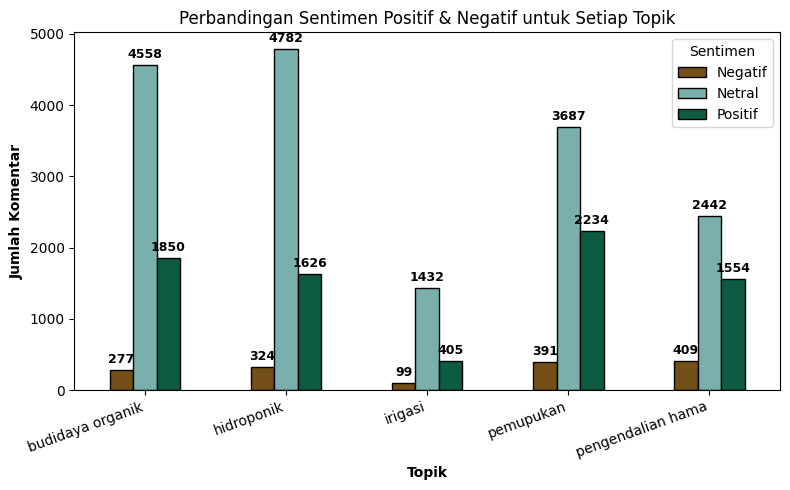

In [33]:
count_data = df.groupby(['topic', 'sentiment']).size().unstack(fill_value=0)

ax = count_data.plot(
    kind='bar',
    figsize=(8, 5),
    color=["#744F18", "#79B0AE", "#0C5B42"],
    edgecolor='black'
)

plt.xlabel('Topik', fontweight='bold')
plt.ylabel('Jumlah Komentar', fontweight='bold')
plt.title('Perbandingan Sentimen Positif & Negatif untuk Setiap Topik')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9, color='black', fontweight='bold', xytext=(0, 3),
            textcoords='offset points'
        )

plt.xticks(rotation=20, ha='right')
plt.legend(title='Sentimen')
plt.tight_layout()
plt.show()

In [34]:
topic_summary = (
    df.groupby(["topic", "sentiment"])
      .size()
      .reset_index(name="count")
)

topic_dict = {}
for topic in topic_summary["topic"].unique():
    subset = topic_summary[topic_summary["topic"] == topic]
    topic_dict[topic] = {
        row["sentiment"]: row["count"]
        for _, row in subset.iterrows()
    }

def tampilkan_pie_chart(topic):
    data = topic_dict.get(topic, {})

    labels = list(data.keys())
    counts = list(data.values())

    if sum(counts) == 0:
        print("Tidak ada data untuk topik ini.")
        return

    colors = ["#0C5B42", "#79B0AE", "#744F18"]

    plt.figure(figsize=(5, 5))
    plt.pie(
        counts,
        labels=[f"{lbl} ({cnt})" for lbl, cnt in zip(labels, counts)],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors[:len(counts)],
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )
    plt.title(f"Persentase Sentimen pada Topik: {topic}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

topic_dropdown = Dropdown(
    options=sorted(df["topic"].dropna().unique()),
    description="Pilih Topik:",
    style={'description_width': 'initial'},
    layout={'width': '50%'}
)

interact(tampilkan_pie_chart, topic=topic_dropdown);

interactive(children=(Dropdown(description='Pilih Topik:', layout=Layout(width='50%'), options=('budidaya orga…

WORDCLOUD TOPIK

In [35]:
def save_image_to_db(image_path, category_name):
    """Fungsi pembantu untuk menyimpan file gambar lokal ke PostgreSQL"""
    try:
        with open(image_path, "rb") as f:
            binary_data = f.read()
        
        table_name = "app_assets"
        
        df_img = pd.DataFrame([{
            'name': category_name,
            'image_data': binary_data,
            'file_type': 'png'
        }])
        
        df_img.to_sql(table_name, engine, if_exists='append', index=False)
        print(f"-> Gambar '{category_name}' sukses diunggah ke database.")
        
    except Exception as e:
        print(f"-> Gagal menyimpan gambar '{category_name}' ke database: {e}")

def tampilkan_visualisasi(topik):
    filtered_data = df[df['topic'].str.lower() == topik.lower()]

    if filtered_data.empty:
        print(f"Tidak ada data untuk topik '{topik}'.")
        return

    safe_topik = topik.replace(" ", "_").lower()

    all_words = ' '.join(filtered_data['stemming'].dropna().astype(str))

    wordcloud = WordCloud(
        width=3000,
        height=2000,
        random_state=42,
        background_color='white',
        colormap='BrBG',
        collocations=False,
        stopwords=STOPWORDS
    ).generate(all_words)

    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {topik}", fontsize=15, fontweight='bold', pad=10)
    
    wc_filename = f"wordcloud_{safe_topik}.png"
    wc_asset_name = f"wordcloud_{safe_topik}"
    
    plt.savefig(wc_filename, dpi=300, bbox_inches='tight') 
    plt.show()                                             
    plt.close()                                            
    
    save_image_to_db(wc_filename, wc_asset_name)         

    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform([all_words])
    word_freq = X.toarray().flatten()
    words = vectorizer.get_feature_names_out()

    word_freq_df = pd.DataFrame({'Word': words, 'Frequency': word_freq})
    word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

    colormap = 'BrBG'
    num_bars = len(word_freq_df['Word'][:20])
    colors = plt.get_cmap(colormap)(np.linspace(0, 1, num_bars))

    plt.figure(figsize=(12, 8))
    bars = plt.bar(word_freq_df['Word'][:20], word_freq_df['Frequency'][:20],
                   color=colors, edgecolor='black')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                 ha='center', va='bottom', fontsize=9, color='black')

    plt.xlabel('Kata', fontweight='bold')
    plt.ylabel('Frekuensi', fontweight='bold')
    plt.title(f"Frekuensi Kata - {topik}", fontsize=15, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    
    freq_filename = f"frekuensi_{safe_topik}.png"
    freq_asset_name = f"frekuensi_{safe_topik}"
    
    plt.savefig(freq_filename, dpi=300, bbox_inches='tight') 
    plt.show()                                               
    plt.close()                                              
    
    save_image_to_db(freq_filename, freq_asset_name)        

topic_dropdown = widgets.Dropdown(
    options=sorted(df['topic'].dropna().unique()),
    description='Pilih Topik:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

interact(tampilkan_visualisasi, topik=topic_dropdown);

interactive(children=(Dropdown(description='Pilih Topik:', layout=Layout(width='50%'), options=('budidaya orga…

##### _Video_

In [36]:
df_kw = pd.read_sql(
    "SELECT topic, sentiment, keyword FROM sentiment_keywords ORDER BY id", engine)

for _, row in df_kw.iterrows():
    topic = row["topic"]
    sentiment = row["sentiment"].lower()
    keyword = row["keyword"].lower()

    if topic not in topic_keywords:
        topic_keywords[topic] = {"positive": [], "neutral": [], "negative": []}

    topic_keywords[topic][sentiment].append(keyword)

def is_relevant(text):
    comment_lower = text.lower()
    return any(keyword in comment_lower for keywords in topic_keywords.values() for keyword in keywords)

def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return None

    clean_comment = re.sub(r"http\S+|www\S+|[^a-zA-Z\s]", " ", text)
    clean_comment = re.sub(r"\s+", " ", clean_comment).strip().lower()

    analysis = TextBlob(clean_comment)
    polarity = analysis.sentiment.polarity

    if polarity > 0.1 and is_relevant(clean_comment):
        return "Positif"
    elif polarity < -0.1:
        return "Negatif"
    else:
        return "Netral"

df = df.copy()

sentiment_per_video_topic = (
    df.groupby(['video_id', 'topic'])['sentiment']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
    .rename_axis(None, axis=1)
)

sentiment_per_video_topic['Persentase_Positif (%)'] = (
    (sentiment_per_video_topic['Positif'] / sentiment_per_video_topic[['Positif', 'Netral', 'Negatif']].sum(axis=1)) * 100
).round(2).astype(str) + '%'

sentiment_per_video_topic['Persentase_Netral (%)'] = (
    (sentiment_per_video_topic['Netral'] / sentiment_per_video_topic[['Positif', 'Netral', 'Negatif']].sum(axis=1)) * 100
).round(2).astype(str) + '%'

sentiment_per_video_topic['Persentase_Negatif (%)'] = (
    (sentiment_per_video_topic['Negatif'] / sentiment_per_video_topic[['Positif', 'Netral', 'Negatif']].sum(axis=1)) * 100
).round(2).astype(str) + '%'

sentiment_per_video_topic['Total'] = sentiment_per_video_topic['Positif'] + sentiment_per_video_topic['Netral'] + sentiment_per_video_topic['Negatif']

sentiment_per_video_topic = sentiment_per_video_topic[
    ['video_id', 'Positif', 'Netral', 'Negatif',
     'Persentase_Positif (%)', 'Persentase_Netral (%)', 'Persentase_Negatif (%)', 'Total']
]

print("Jumlah dan Persentase Sentimen per Video:")
display(sentiment_per_video_topic)

output_file = "data/Sentiment_per_Video.csv"
sentiment_per_video_topic.to_csv(output_file, index=False)
print(f"Analisis sentimen per video selesai dan disimpan ke '{output_file}'")

with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS sentiment_per_video_topic;"))
    conn.commit()

sentiment_per_video_topic.to_sql(
    "sentiment_per_video",
    engine,
    if_exists="replace",
    index=False)

print("Data sentiment per video berhasil disimpan ke PostgreSQL!")

Jumlah dan Persentase Sentimen per Video:


,video_id,Positif,Netral,Negatif,Persentase_Positif (%),Persentase_Netral (%),Persentase_Negatif (%),Total
0,-GyJN1tr9RM,693,2080,44,24.6%,73.84%,1.56%,2817
1,-YlHpqcgOow,309,538,64,33.92%,59.06%,7.03%,911
2,1NnDgJzBAq4,156,491,35,22.87%,71.99%,5.13%,682
3,28Eo_Xm8LYg,448,879,116,31.05%,60.91%,8.04%,1443
4,3MeyTr2kdBg,86,153,16,33.73%,60.0%,6.27%,255
5,4CTYII_qHCQ,215,205,15,49.43%,47.13%,3.45%,435
6,59vXGu65IS4,54,86,5,37.24%,59.31%,3.45%,145
7,5Fv2tGv9_Vo,1070,2840,128,26.5%,70.33%,3.17%,4038
8,9zyK_C4g4qU,70,340,39,15.59%,75.72%,8.69%,449
9,AQLcjhHQBC0,35,256,24,11.11%,81.27%,7.62%,315


Analisis sentimen per video selesai dan disimpan ke 'data/Sentiment_per_Video.csv'
Data sentiment per video berhasil disimpan ke PostgreSQL!


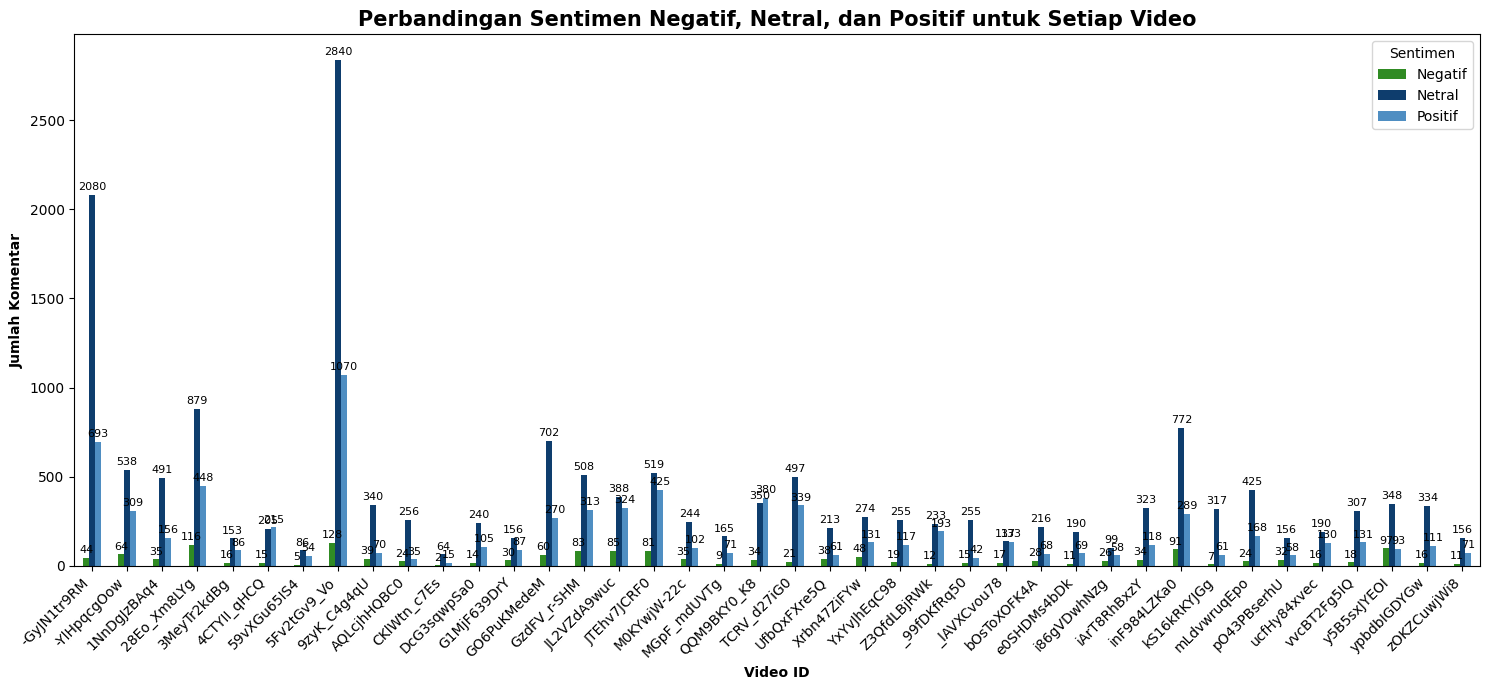

In [37]:
count_data = df.groupby(['video_id', 'topic', 'sentiment']).size().unstack(fill_value=0).reset_index()

fig, ax = plt.subplots(figsize=(15, 7))

count_data.plot(
    x='video_id',
    kind='bar',
    stacked=False,
    color=["#308b23", "#0E3D6D", "#4F8EC2"],
    ax=ax
)

plt.xlabel('Video ID', fontweight='bold')
plt.ylabel('Jumlah Komentar', fontweight='bold')
plt.title('Perbandingan Sentimen Negatif, Netral, dan Positif untuk Setiap Video', fontsize=15, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8, padding=2)

plt.xticks(
    ticks=range(len(count_data)),
    labels=count_data['video_id'],
    rotation=45,
    ha='right'
)
plt.legend(title='Sentimen', labels=['Negatif', 'Netral', 'Positif'])
plt.tight_layout()
plt.show()

In [38]:
def tampilkan_pie_chart_video(video_id):
    df_video = df[df["video_id"] == video_id]

    sentiment_counts = df_video["sentiment"].value_counts()
    sentiment_percent = (sentiment_counts / sentiment_counts.sum()) * 100

    colors = ["#4F8EC2", "#0E3D6D", "#308b23"]

    plt.figure(figsize=(5, 5))
    plt.pie(
        sentiment_counts,
        labels=[
            f"{label} ({count})"
            for label, count, percent in zip(sentiment_counts.index, sentiment_counts, sentiment_percent)
        ],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    plt.title(f"Persentase Sentimen Komentar untuk Video ID: {video_id}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

video_dropdown = Dropdown(
    options=sorted(df["video_id"].unique()),
    description="Pilih Video ID:",
    style={'description_width': 'initial'},
    layout={'width': '50%'}
)

interact(tampilkan_pie_chart_video, video_id=video_dropdown);

interactive(children=(Dropdown(description='Pilih Video ID:', layout=Layout(width='50%'), options=('-GyJN1tr9R…

WORDCLOUD VIDEO

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
import ipywidgets as widgets
from ipywidgets import interact

def save_image_to_db(image_path, category_name):
    """Fungsi pembantu untuk menyimpan file gambar lokal ke PostgreSQL"""
    try:
        with open(image_path, "rb") as f:
            binary_data = f.read()
        
        table_name = "app_assets"
        
        df_img = pd.DataFrame([{
            'name': category_name,
            'image_data': binary_data,
            'file_type': 'png'
        }])
        
        df_img.to_sql(table_name, engine, if_exists='append', index=False)
        print(f"-> Gambar '{category_name}' sukses diunggah ke database.")
        
    except Exception as e:
        print(f"-> Gagal menyimpan gambar '{category_name}' ke database: {e}")

df['topic'] = df['topic'].astype(str).str.lower()

def tampilkan_visualisasi(video_id):
    df_video = df[df['video_id'] == video_id]

    if df_video.empty:
        print(f"Tidak ada data untuk video_id '{video_id}'.")
        return

    safe_video = video_id.replace(" ", "_").lower()

    all_words = ' '.join(df_video['stemming'].astype(str))

    wordcloud = WordCloud(
        width=3000, height=2000,
        random_state=3, background_color='white',
        colormap='ocean', collocations=False,
        stopwords=STOPWORDS
    ).generate(all_words)

    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud untuk Video ID: {video_id}", fontsize=15, fontweight='bold')
    
    wc_filename = f"wordcloud_{safe_video}.png"
    wc_asset_name = f"wordcloud_{safe_video}"
    
    plt.savefig(wc_filename, dpi=300, bbox_inches='tight') 
    plt.show()                                             
    plt.close()                                             
    
    save_image_to_db(wc_filename, wc_asset_name)           

    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform([all_words])
    word_freq = X.toarray().flatten()
    words = vectorizer.get_feature_names_out()

    word_freq_df = pd.DataFrame({'Word': words, 'Frequency': word_freq})
    word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

    colormap = 'ocean'
    num_bars = len(word_freq_df['Word'][:20])
    colors = plt.get_cmap(colormap)(np.linspace(0, 1, num_bars))

    plt.figure(figsize=(12, 6))
    bars = plt.bar(word_freq_df['Word'][:20], word_freq_df['Frequency'][:20],
                   color=colors, edgecolor='black')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                 ha='center', va='bottom', fontsize=15, color='black')

    plt.xlabel('Kata', fontweight='bold')
    plt.ylabel('Frekuensi', fontweight='bold')
    plt.title(f"Frekuensi Kata pada Video ID: {video_id}", fontsize=13, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    
    freq_filename = f"frekuensi_{safe_video}.png"
    freq_asset_name = f"frekuensi_{safe_video}"
    
    plt.savefig(freq_filename, dpi=300, bbox_inches='tight')  
    plt.show()                                                
    plt.close()                                               
    
    save_image_to_db(freq_filename, freq_asset_name)         

video_dropdown = widgets.Dropdown(
    options=sorted(df['video_id'].unique()),
    description='Pilih Video ID:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

interact(tampilkan_visualisasi, video_id=video_dropdown);

interactive(children=(Dropdown(description='Pilih Video ID:', layout=Layout(width='50%'), options=('-GyJN1tr9R…

##### _kategori_

In [40]:
df_kw = pd.read_sql("SELECT topic, sentiment, keyword FROM sentiment_keywords", engine)

df_kw["keyword"] = df_kw["keyword"].str.lower().str.strip()
df_kw["sentiment"] = df_kw["sentiment"].str.lower().str.strip()

sentiment_dict = {
    "positive": df_kw[df_kw["sentiment"] == "positive"]["keyword"].tolist(),
    "negative": df_kw[df_kw["sentiment"] == "negative"]["keyword"].tolist()
}

df_sent = df.copy()

df_sent["category"] = df_sent["category"].str.split(", ")
df_sent = df_sent.explode("category")

def get_sentiment(text):

    if not isinstance(text, str) or text.strip() == "":
        return "Netral"

    clean_text = re.sub(r"http\S+|www\S+|[^a-zA-Z\s]", " ", text)
    clean_text = re.sub(r"\s+", " ", clean_text).strip().lower()

    pos_score = 0
    neg_score = 0

    for word in sentiment_dict["positive"]:
        if word in clean_text:
            pos_score += 1

    for word in sentiment_dict["negative"]:
        if word in clean_text:
            neg_score += 1

    if pos_score > neg_score:
        return "Positif"
    elif neg_score > pos_score:
        return "Negatif"

    polarity = TextBlob(clean_text).sentiment.polarity

    if polarity > 0.1:
        return "Positif"
    elif polarity < -0.1:
        return "Negatif"
    else:
        return "Netral"

df_sent["sentiment"] = df_sent["comment"].apply(get_sentiment)

sentiment_per_category = (
    df_sent
    .groupby("category")["sentiment"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ["Positif", "Netral", "Negatif"]:
    if col not in sentiment_per_category.columns:
        sentiment_per_category[col] = 0

sentiment_per_category["Total"] = (
    sentiment_per_category["Positif"] +
    sentiment_per_category["Netral"] +
    sentiment_per_category["Negatif"]
)

sentiment_per_category["Persentase_Positif (%)"] = (
    (sentiment_per_category["Positif"] / sentiment_per_category["Total"]) * 100
).fillna(0).round(2).astype(str) + "%"

sentiment_per_category["Persentase_Netral (%)"] = (
    (sentiment_per_category["Netral"] / sentiment_per_category["Total"]) * 100
).fillna(0).round(2).astype(str) + "%"

sentiment_per_category["Persentase_Negatif (%)"] = (
    (sentiment_per_category["Negatif"] / sentiment_per_category["Total"]) * 100
).fillna(0).round(2).astype(str) + "%"

sentiment_per_category = sentiment_per_category[
    ["category", "Positif", "Netral", "Negatif", "Persentase_Positif (%)", "Persentase_Netral (%)", "Persentase_Negatif (%)", "Total"]
].sort_values("Total", ascending=False).reset_index(drop=True)

sentiment_per_category.index.name = None
sentiment_per_category.columns.name = None

print("Jumlah dan Persentase Sentimen per category:")
display(sentiment_per_category)

output_file = "data/Sentimen_Per_Category.csv"
sentiment_per_category.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Analisis sentimen per kategori selesai. File disimpan di: {output_file}")

with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS sentiment_per_category;"))
    conn.commit()

sentiment_per_video_topic.to_sql(
    "sentiment_per_category",
    engine,
    if_exists="replace",
    index=False
)
print("Data sentiment per kategori berhasil disimpan ke PostgreSQL!")

Jumlah dan Persentase Sentimen per category:


,category,Positif,Netral,Negatif,Persentase_Positif (%),Persentase_Netral (%),Persentase_Negatif (%),Total
0,feedback penonton,544,17626,89,2.98%,96.53%,0.49%,18259
1,kompleksitas perawatan,16,2132,2,0.74%,99.16%,0.09%,2150
2,dosis dan waktu pupuk,33,1758,9,1.83%,97.67%,0.5%,1800
3,konflik pupuk kimia organik,34,1002,6,3.26%,96.16%,0.58%,1042
4,minat konsumen organik,23,615,7,3.57%,95.35%,1.09%,645
5,efektivitas pengendalian hama,9,503,1,1.75%,98.05%,0.19%,513
6,kepercayaan produk organik,26,353,2,6.82%,92.65%,0.52%,381
7,minat hidroponik,8,331,2,2.35%,97.07%,0.59%,341
8,hasil panen organik,19,315,4,5.62%,93.2%,1.18%,338
9,biaya awal hidroponik,4,331,0,1.19%,98.81%,0.0%,335


Analisis sentimen per kategori selesai. File disimpan di: data/Sentimen_Per_Category.csv
Data sentiment per kategori berhasil disimpan ke PostgreSQL!


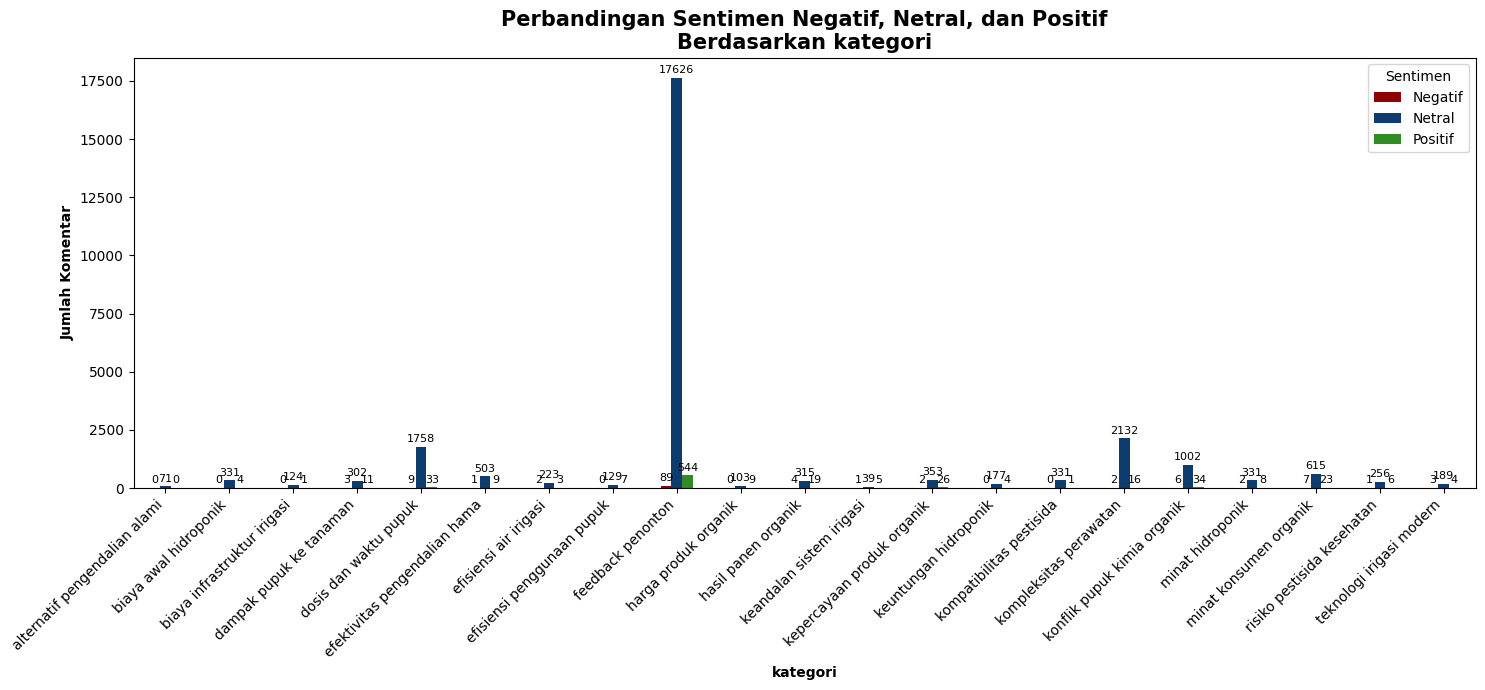

In [41]:
count_data = (
    df_sent
    .groupby(['category', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['Negatif', 'Netral', 'Positif']:
    if col not in count_data.columns:
        count_data[col] = 0

fig, ax = plt.subplots(figsize=(15, 7))

count_data.plot(
    x='category',
    kind='bar',
    stacked=False,
    color=["#8B0303", "#0E3D6D", "#308b23"],
    ax=ax
)

plt.xlabel('kategori', fontweight='bold')
plt.ylabel('Jumlah Komentar', fontweight='bold')
plt.title(
    'Perbandingan Sentimen Negatif, Netral, dan Positif\nBerdasarkan kategori',
    fontsize=15,
    fontweight='bold'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8, padding=2)

plt.xticks(
    ticks=range(len(count_data)),
    labels=count_data['category'],
    rotation=45,
    ha='right'
)

plt.legend(title='Sentimen', labels=['Negatif', 'Netral', 'Positif'])

plt.tight_layout()
plt.show()

In [42]:
def tampilkan_pie_chart_category(category):
    
    df_category = df_sent[df_sent["category"] == category]
    sentiment_counts = df_category["sentiment"].value_counts()

    if sentiment_counts.sum() == 0:
        print("Tidak ada data untuk kategori ini.")
        return

    sentiment_order = ["Negatif", "Netral", "Positif"]
    sentiment_counts = sentiment_counts.reindex(sentiment_order, fill_value=0)

    sentiment_counts = sentiment_counts[sentiment_counts > 0]

    colors_map = {
        "Negatif": "#8B0303", "Netral": "#0E3D6D", "Positif": "#308b23"}

    colors = [colors_map[label] for label in sentiment_counts.index]

    plt.figure(figsize=(6, 6))
    plt.pie(
        sentiment_counts,
        labels=[f"{label} ({count})" 
                for label, count in zip(sentiment_counts.index, sentiment_counts)],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 11, 'fontweight': 'bold'},
        labeldistance=1.1,    
        pctdistance=0.7       
    )

    plt.title(
        f"Persentase Sentimen Komentar\nkategori: {category}",
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

category_dropdown = Dropdown(
    options=sorted(df_sent["category"].dropna().unique()),
    description="Pilih kategori:",
    style={'description_width': 'initial'},
    layout={'width': '50%'}
)

interact(tampilkan_pie_chart_category, category=category_dropdown);

interactive(children=(Dropdown(description='Pilih kategori:', layout=Layout(width='50%'), options=('alternatif…

WORDCLOUD KATEGORI

In [43]:
def save_image_to_db(image_path, category_name):
    """Fungsi pembantu untuk menyimpan file gambar lokal ke PostgreSQL"""
    try:
        with open(image_path, "rb") as f:
            binary_data = f.read()
        
        table_name = "app_assets"
        
        df_img = pd.DataFrame([{
            'name': category_name,
            'image_data': binary_data,
            'file_type': 'png'
        }])
        
        df_img.to_sql(table_name, engine, if_exists='append', index=False)
        print(f"-> Gambar '{category_name}' sukses diunggah ke database.")
        
    except Exception as e:
        print(f"-> Gagal menyimpan gambar '{category_name}' ke database: {e}")

def tampilkan_visualisasi(category):
    
    filtered_data = df_sent[df_sent['category'].str.lower() == category.lower()]

    if filtered_data.empty:
        print(f"Tidak ada data untuk kategori '{category}'.")
        return

    safe_category = category.replace(" ", "_").lower()
    all_words = ' '.join(filtered_data['stemming'].dropna().astype(str))

    if all_words.strip() == "":
        print("Data teks kosong untuk kategori ini.")
        return

    wordcloud = WordCloud(
        width=3000,
        height=2000,
        random_state=42,
        background_color='white',
        colormap='BrBG',
        collocations=False,
        stopwords=STOPWORDS
    ).generate(all_words)

    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {category}", fontsize=15, fontweight='bold', pad=10)
    
    wc_filename = f"wordcloud_{safe_category}.png"
    wc_asset_name = f"wordcloud_{safe_category}"
    
    plt.savefig(wc_filename, dpi=300, bbox_inches='tight') 
    plt.show()                                              
    plt.close()                                            
    
    save_image_to_db(wc_filename, wc_asset_name)          

    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform([all_words])
    word_freq = X.toarray().flatten()
    words = vectorizer.get_feature_names_out()

    word_freq_df = pd.DataFrame({'Word': words, 'Frequency': word_freq})
    word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

    colormap = 'brg'
    num_bars = min(20, len(word_freq_df))
    colors = plt.get_cmap(colormap)(np.linspace(0, 1, num_bars))

    plt.figure(figsize=(12, 8))
    bars = plt.bar(
        word_freq_df['Word'][:20],
        word_freq_df['Frequency'][:20],
        color=colors,
        edgecolor='black'
    )

    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval,
            int(yval),
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.xlabel('Kata', fontweight='bold')
    plt.ylabel('Frekuensi', fontweight='bold')
    plt.title(f"Frekuensi Kata - {category}", fontsize=15, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    
    freq_filename = f"frekuensi_{safe_category}.png"
    freq_asset_name = f"frekuensi_{safe_category}"
    
    plt.savefig(freq_filename, dpi=300, bbox_inches='tight') 
    plt.show()                                               
    plt.close()                                               
    
    save_image_to_db(freq_filename, freq_asset_name)       

category_dropdown = widgets.Dropdown(
    options=sorted(df_sent['category'].dropna().unique()),
    description='Pilih kategori:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

interact(tampilkan_visualisasi, category=category_dropdown);

interactive(children=(Dropdown(description='Pilih kategori:', layout=Layout(width='50%'), options=('alternatif…

SEBELUM BALANCING

##### _Naive Bayes_

Jumlah Data Latih: 20856
Jumlah Data Uji: 5214

Accuracy: 0.8450326045262754
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.78      0.27      0.40       326
      Netral       0.91      0.89      0.90      3356
     Positif       0.73      0.88      0.80      1532

    accuracy                           0.85      5214
   macro avg       0.81      0.68      0.70      5214
weighted avg       0.85      0.85      0.84      5214



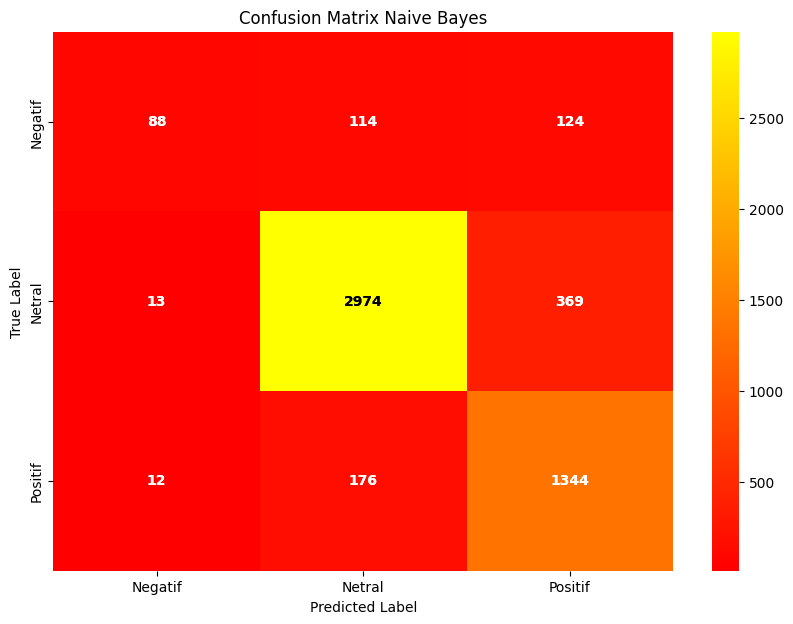

Confusion Matrix:
 [[  88  114  124]
 [  13 2974  369]
 [  12  176 1344]]


In [44]:
X = df['stemming']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(f'Jumlah Data Latih: {len(X_train)}')
print(f'Jumlah Data Uji: {len(X_test)}')
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,    annot=True,    fmt='d',    cmap='autumn',    xticklabels=model.classes_,
    yticklabels=model.classes_,    annot_kws={"size": 10, "weight": "bold"}, cbar=True)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        color = 'white' if value < cm.max() / 2 else 'black'
        plt.text(j + 0.5, i + 0.5, str(value),
                 ha='center', va='center', color=color, fontsize=10, fontweight='bold')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Naive Bayes')
plt.show()
print("Confusion Matrix:\n", cm)

In [45]:
def class_accuracies(conf_matrix):
    true_positive = np.diag(conf_matrix)
    total_per_class = np.sum(conf_matrix, axis=1)
    accuracies = true_positive / total_per_class
    return accuracies
accuracies = class_accuracies(cm)
for label, acc in zip(model.classes_, accuracies):
    print(f'Akurasi Kelas {label}: {acc * 100:.2f}%')

Akurasi Kelas Negatif: 26.99%
Akurasi Kelas Netral: 88.62%
Akurasi Kelas Positif: 87.73%


In [46]:
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
threshold_list = [0.2, 0.1]

for test_size in threshold_list:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
results = pd.DataFrame({
    'Training Data Percentage': [80, 90],
    'Accuracy': accuracy_list, 'Precision': precision_list, 'Recall': recall_list, 'F1 Score': f1_list})
results.to_csv('result_nb.csv', index=False)
table_name = "result_nb"
results.to_sql(
    name=table_name, 
    con=engine, 
    if_exists='replace', 
    index=False
)
print(results)

   Training Data Percentage  Accuracy  Precision    Recall  F1 Score
0                        80  0.845033   0.850126  0.845033  0.837812
1                        90  0.853855   0.858651  0.853855  0.847293


In [47]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)

              precision    recall  f1-score      support
Negatif        0.807018  0.292994  0.429907   157.000000
Netral         0.914634  0.893389  0.903887  1679.000000
Positif        0.747253  0.881971  0.809042   771.000000
accuracy       0.853855  0.853855  0.853855     0.853855
macro avg      0.822968  0.689451  0.714278  2607.000000
weighted avg   0.858651  0.853855  0.847293  2607.000000


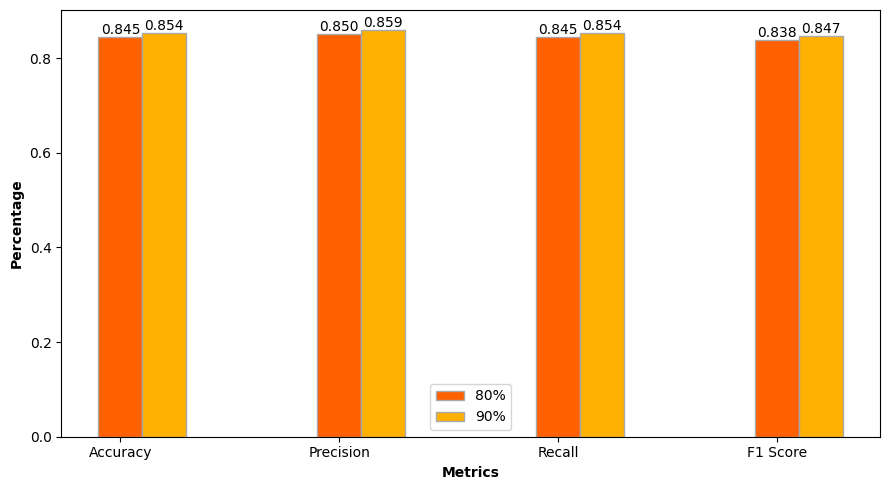

In [48]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values_80 = results[results['Training Data Percentage'] == 80].iloc[0, 1:].values
values_90 = results[results['Training Data Percentage'] == 90].iloc[0, 1:].values

bar_width = 0.2
r1 = np.arange(len(categories))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

plt.figure(figsize=(9, 5))
bars_80 = plt.bar(r2, values_80, color="#FF6000", width=bar_width, edgecolor='darkgrey', label='80%')
bars_90 = plt.bar(r3, values_90, color="#FFB000", width=bar_width, edgecolor='darkgrey', label='90%')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=10)
add_labels(bars_80)
add_labels(bars_90)

plt.xlabel('Metrics', fontweight='bold')
plt.ylabel('Percentage', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(categories))], categories)
plt.legend()
plt.tight_layout()
plt.show()

##### _Support Vector Machine_

Jumlah Data Latih: 20856
Jumlah Data Uji: 5214

Accuracy: 0.9305715381664749
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.81      0.71      0.76       326
      Netral       0.95      0.96      0.95      3356
     Positif       0.90      0.92      0.91      1532

    accuracy                           0.93      5214
   macro avg       0.89      0.86      0.87      5214
weighted avg       0.93      0.93      0.93      5214



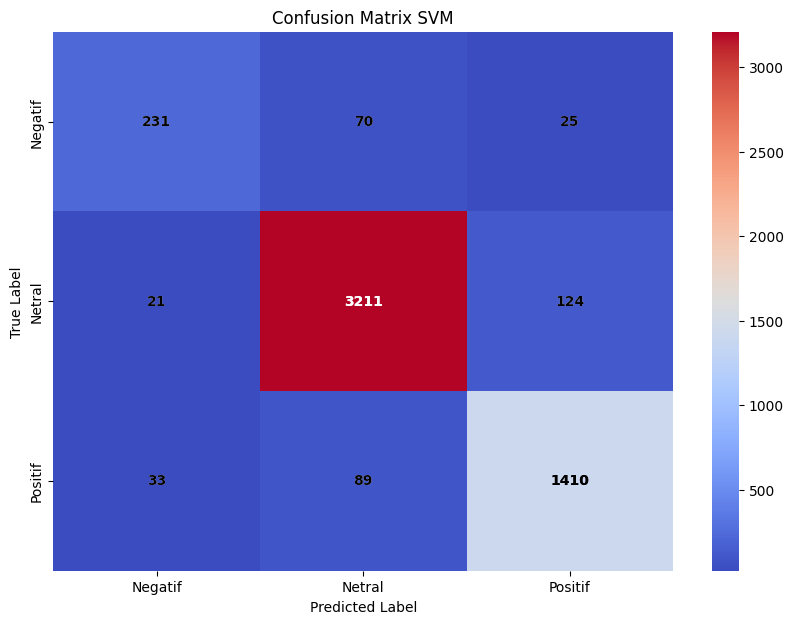

Confusion Matrix:
 [[ 231   70   25]
 [  21 3211  124]
 [  33   89 1410]]


In [49]:
X = df['stemming']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
model = SVC(kernel='linear', random_state=42)
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(f'Jumlah Data Latih: {len(X_train)}')
print(f'Jumlah Data Uji: {len(X_test)}')
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=model.classes_,
    yticklabels=model.classes_,    annot_kws={"size": 10, "weight": "bold"}, cbar=True)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        color = 'black' if value < cm.max() / 2 else 'white'
        plt.text(j + 0.5, i + 0.5, str(value),
                 ha='center', va='center', color=color, fontsize=10, fontweight='bold')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix SVM')
plt.show()
print("Confusion Matrix:\n", cm)

In [50]:
def class_accuracies(conf_matrix):
    true_positive = np.diag(conf_matrix)
    total_per_class = np.sum(conf_matrix, axis=1)
    accuracies = true_positive / total_per_class
    return accuracies
accuracies = class_accuracies(cm)
for label, acc in zip(model.classes_, accuracies):
    print(f'Akurasi Kelas {label}: {acc * 100:.2f}%')

Akurasi Kelas Negatif: 70.86%
Akurasi Kelas Netral: 95.68%
Akurasi Kelas Positif: 92.04%


In [51]:
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
threshold_list = [0.2, 0.1]
vectorizer = CountVectorizer()
model = SVC(kernel='linear', random_state=42)

for test_size in threshold_list:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

results = pd.DataFrame({
    'Training Data Percentage': [100 - int(ts * 100) for ts in threshold_list], 'Accuracy': accuracy_list,
    'Precision': precision_list, 'Recall': recall_list,    'F1 Score': f1_list})
results.to_csv('result_svm.csv', index=False)
table_name = "result_svm"
results.to_sql(
    name=table_name, 
    con=engine, 
    if_exists='replace', 
    index=False
)
print(results)

   Training Data Percentage  Accuracy  Precision    Recall  F1 Score
0                        80  0.930572   0.929703  0.930572  0.929900
1                        90  0.928270   0.927427  0.928270  0.927767


In [52]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)

              precision    recall  f1-score     support
Negatif        0.772414  0.713376  0.741722   157.00000
Netral         0.949203  0.957117  0.953144  1679.00000
Positif        0.911573  0.909209  0.910390   771.00000
accuracy       0.928270  0.928270  0.928270     0.92827
macro avg      0.877730  0.859901  0.868418  2607.00000
weighted avg   0.927427  0.928270  0.927767  2607.00000


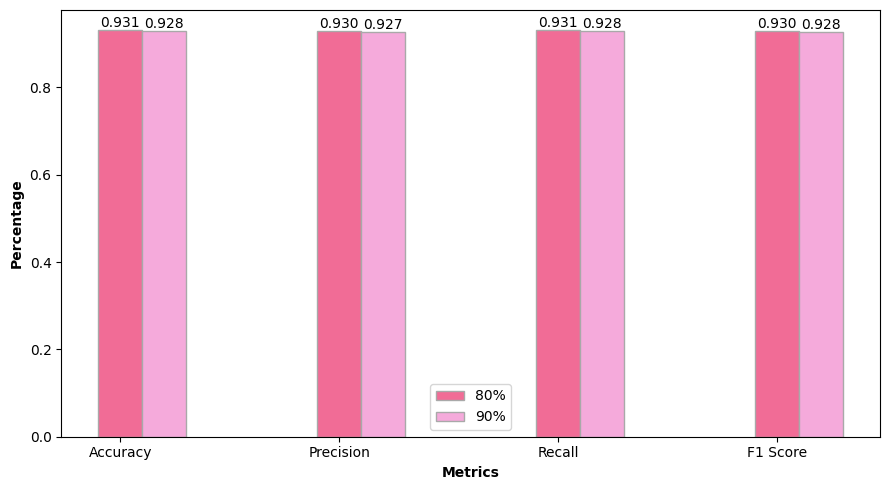

In [53]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values_80 = results[results['Training Data Percentage'] == 80].iloc[0, 1:].values
values_90 = results[results['Training Data Percentage'] == 90].iloc[0, 1:].values

bar_width = 0.2
r1 = np.arange(len(categories))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

plt.figure(figsize=(9, 5))
bars_80 = plt.bar(r2, values_80, color="#f16c96", width=bar_width, edgecolor='darkgrey', label='80%')
bars_90 = plt.bar(r3, values_90, color="#f5aadb", width=bar_width, edgecolor='darkgrey', label='90%')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=10)
add_labels(bars_80)
add_labels(bars_90)

plt.xlabel('Metrics', fontweight='bold')
plt.ylabel('Percentage', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(categories))], categories)
plt.legend()
plt.tight_layout()
plt.show()

##### _Long Short Term Memory_

Epoch 1/5
522/522 ━━━━━━━━━━━━━━━━━━━━ 234s 430ms/step - accuracy: 0.6470 - loss: -62.9972 - val_accuracy: 0.6570 - val_loss: -478.3022
Epoch 2/5
522/522 ━━━━━━━━━━━━━━━━━━━━ 203s 390ms/step - accuracy: 0.6489 - loss: -789.0489 - val_accuracy: 0.6570 - val_loss: -1766.0914
Epoch 3/5
522/522 ━━━━━━━━━━━━━━━━━━━━ 217s 416ms/step - accuracy: 0.6495 - loss: -2356.5151 - val_accuracy: 0.6570 - val_loss: -3778.0513
Epoch 4/5
522/522 ━━━━━━━━━━━━━━━━━━━━ 202s 388ms/step - accuracy: 0.6466 - loss: -4591.7773 - val_accuracy: 0.6570 - val_loss: -6409.7202
Epoch 5/5
522/522 ━━━━━━━━━━━━━━━━━━━━ 201s 383ms/step - accuracy: 0.6478 - loss: -7564.4575 - val_accuracy: 0.6570 - val_loss: -9584.0762
163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step

Jumlah Data Latih: 20856
Jumlah Data Uji: 5214

Accuracy: 0.6436517069428462
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00       326
      Netral       0.64      1.00      0.78      3356


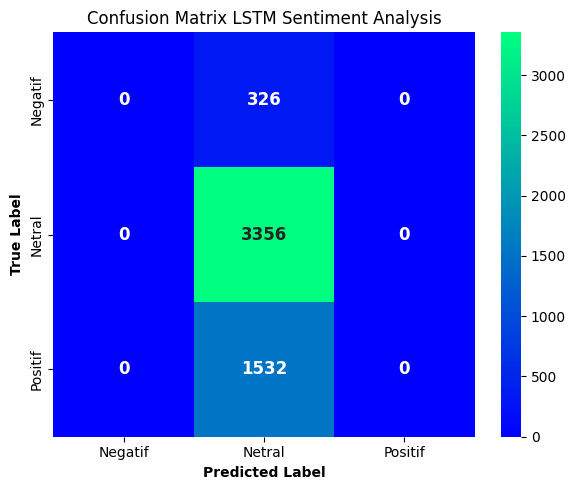


Confusion Matrix:
 [[   0  326    0]
 [   0 3356    0]
 [   0 1532    0]]


In [54]:
X = df['stemming'].astype(str)
y = df['sentiment']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

maxlen = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

model = Sequential([
    Embedding(input_dim=5000, output_dim=128),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=1)

y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(f'\nJumlah Data Latih: {len(X_train)}')
print(f'Jumlah Data Uji: {len(X_test)}')
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_,
                                                        zero_division=0))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='winter',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar=True, annot_kws={"size": 12, "weight": "bold"})

plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('Confusion Matrix LSTM Sentiment Analysis')
plt.tight_layout()
plt.show()
print("\nConfusion Matrix:\n", cm)

In [55]:
def class_accuracies(conf_matrix):
    true_positive = np.diag(conf_matrix)
    total_per_class = np.sum(conf_matrix, axis=1)
    accuracies = true_positive / total_per_class
    return accuracies

accuracies = class_accuracies(cm)
class_labels = ['Negatif', 'Netral', 'Positif']

for label, acc in zip(class_labels, accuracies):
    print(f'Akurasi Kelas {label}: {acc * 100:.2f}%')

Akurasi Kelas Negatif: 0.00%
Akurasi Kelas Netral: 100.00%
Akurasi Kelas Positif: 0.00%


In [56]:
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

threshold_list = [0.2, 0.1]

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

le = LabelEncoder()
y = le.fit_transform(y)

for test_size in threshold_list:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_test_seq = tokenizer.texts_to_sequences(X_test)
    X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
    X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post')

    vocab_size = len(tokenizer.word_index) + 1
    model = Sequential([
        Embedding(vocab_size, 128),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=0)

    y_pred_prob = model.predict(X_test_pad)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

results = pd.DataFrame({
    'Training Data Percentage': [100 - int(ts * 100) for ts in threshold_list],
    'Accuracy': accuracy_list,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1 Score': f1_list
})
results.to_csv('result_lstm.csv', index=False)
table_name = "result_lstm"
results.to_sql(
    name=table_name, 
    con=engine, 
    if_exists='replace', 
    index=False
)
print(results.to_string(index=False))

163/163 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step
 Training Data Percentage  Accuracy  Precision   Recall  F1 Score
                       80  0.643652   0.414288 0.643652  0.504106
                       90  0.644035   0.414781 0.644035  0.504589


In [57]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)

              precision    recall  f1-score      support
0              0.000000  0.000000  0.000000   157.000000
1              0.644035  1.000000  0.783481  1679.000000
2              0.000000  0.000000  0.000000   771.000000
accuracy       0.644035  0.644035  0.644035     0.644035
macro avg      0.214678  0.333333  0.261160  2607.000000
weighted avg   0.414781  0.644035  0.504589  2607.000000


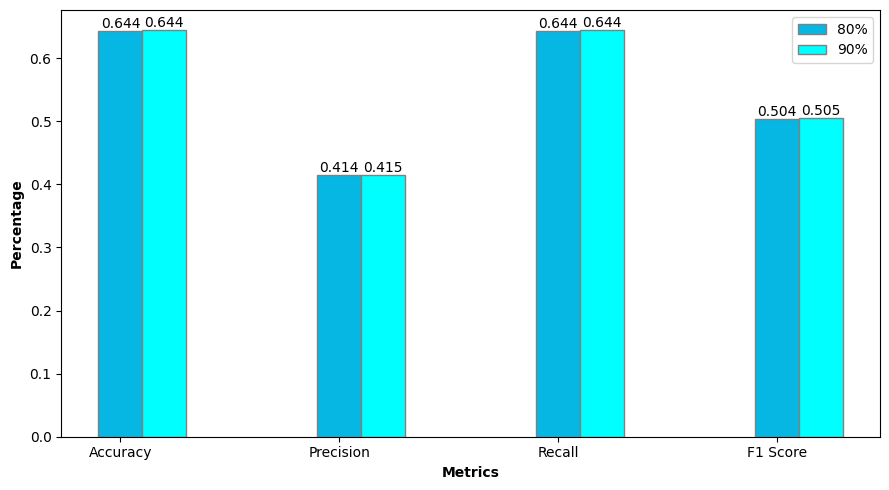

In [58]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values_80 = results[results['Training Data Percentage'] == 80].iloc[0, 1:].values
values_90 = results[results['Training Data Percentage'] == 90].iloc[0, 1:].values

bar_width = 0.2
r1 = np.arange(len(categories))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

plt.figure(figsize=(9, 5))
bars_80 = plt.bar(r2, values_80, color="#06B7E3", width=bar_width, edgecolor='grey', label='80%')
bars_90 = plt.bar(r3, values_90, color="#00FFFF", width=bar_width, edgecolor='grey', label='90%')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=10)
add_labels(bars_80)
add_labels(bars_90)

plt.xlabel('Metrics', fontweight='bold')
plt.ylabel('Percentage', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(categories))], categories)
plt.legend()
plt.tight_layout()
plt.show()

BALANCING TEST

In [59]:
df = df.replace(r'^\s*$', np.nan, regex=True)
df_clean = df.dropna(how='any')

print("Jumlah data kosong per kolom:")
print(df_clean.isna().sum())
print()

positive = df_clean[df_clean['sentiment'] == "Positif"]
neutral = df_clean[df_clean['sentiment'] == "Netral"]
negative = df_clean[df_clean['sentiment'] == "Negatif"]

min_count = min(len(positive), len(negative))

positive_sampled = positive.sample(min_count, random_state=42)
neutral_sampled = neutral.sample(min_count, random_state=42)
negative_sampled = negative.sample(min_count, random_state=42)

df_balanced = pd.concat([positive_sampled, neutral_sampled, negative_sampled]).sample(frac=1, random_state=42)

print("Jumlah data balanced:")
print(df_balanced['sentiment'].value_counts())
print()

df_balanced.to_csv("data_balanced.csv", index=False)
print("Hasil balanced disimpan ke: data_balanced.csv")

table_name = "data_balanced"
df_balanced.to_sql(
    name=table_name, 
    con=engine, 
    if_exists='replace', 
    index=False
)
print(f"Hasil balanced sukses diunggah ke PostgreSQL pada tabel '{table_name}'!\n")

data = pd.read_csv("data_balanced.csv")
data

Jumlah data kosong per kolom:
video_id         0
author           0
comment          0
like_count       0
date             0
topic            0
year             0
normalization    0
tokenizing       0
stopword         0
stemming         0
category         0
sentiment        0
dtype: int64

Jumlah data balanced:
sentiment
Positif    1496
Negatif    1496
Netral     1496
Name: count, dtype: int64

Hasil balanced disimpan ke: data_balanced.csv
Hasil balanced sukses diunggah ke PostgreSQL pada tabel 'data_balanced'!



,video_id,author,comment,like_count,date,topic,year,normalization,tokenizing,stopword,stemming,category,sentiment
0,-GyJN1tr9RM,@AhmadMaulana-ci5tq,kebetulan disebelah rumah ada lahan kosong mau...,2,2024-02-14T08:09:21Z,hidroponik,2024,kebetulan disebelah rumah ada lahan kosong mau...,"kebetulan, disebelah, rumah, ada, lahan, koson...","disebelah, rumah, lahan, kosong, coba, bertana...","belah, rumah, lahan, kosong, coba, tanam, tpi,...","kompleksitas perawatan, minat hidroponik",Positif
1,YxYvJhEqC98,@muhajir1103,omong kosong bagaimana kurang minat pemuda dal...,0,2022-11-17T07:03:26Z,budidaya organik,2022,omong kosong bagaimana kurang minat pemuda dal...,"omong, kosong, bagaimana, kurang, minat, pemud...","omong, kosong, minat, pemuda, pertanian, kalo,...","omong, kosong, minat, pemuda, tani, kalo, penu...",minat konsumen organik,Negatif
2,-GyJN1tr9RM,@esihjua19,terima kasih pak ilmunya sangat bermanfaat men...,6,2023-02-10T07:35:09Z,hidroponik,2023,terima kasih pak ilmunya sangat bermanfaat men...,"terima, kasih, pak, ilmunya, sangat, bermanfaa...","terima, kasih, ilmunya, bermanfaat, menginsipi...","terima, kasih, ilmu, manfaat, insipirasi",feedback penonton,Positif
3,-GyJN1tr9RM,@yuditkost1666,om bikin nutrisi yg alami penganti a b mksih,6,2022-07-17T23:13:00Z,hidroponik,2022,om bikin nutrisi yg alami penganti a b mksih,"om, bikin, nutrisi, yg, alami, penganti, a, b,...","om, bikin, nutrisi, yg, alami, penganti, a, b,...","om, bikin, nutrisi, yg, alami, anti, a, b, mksih",kompleksitas perawatan,Positif
4,ucfHy84xvec,@iisistiqomah8172,masya allah keren sekaliii kalau jadi tetangga...,1,2024-12-20T11:08:53Z,budidaya organik,2024,masya allah keren sekaliii kalau jadi tetangga...,"masya, allah, keren, sekaliii, kalau, jadi, te...","masya, allah, keren, sekaliii, tetangga, langg...","masya, allah, ren, sekaliii, tetangga, langgan...","hasil panen organik, kepercayaan produk organik",Positif
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4483,GzdFV_r-SHM,@alimaruf348,apakah utk semprot siput mati pak,0,2025-06-08T04:07:34Z,pengendalian hama,2025,apakah utk semprot siput mati pak,"apakah, utk, semprot, siput, mati, pak","utk, semprot, siput, mati","utk, semprot, siput, mati",efektivitas pengendalian hama,Negatif
4484,JTEhv7JCRF0,@kopihitam3696,terimakasih pak saya merasakan bayak kemasukan...,0,2025-01-28T07:36:12Z,pengendalian hama,2025,terimakasih pak saya merasakan bayak kemasukan...,"terimakasih, pak, saya, merasakan, bayak, kema...","terimakasih, merasakan, bayak, kemasukan, berguna","terimakasih, rasa, bayak, masuk, guna",feedback penonton,Positif
4485,JL2VZdA9wuc,@zaenahmad9652,mau nanya bang apa bisa untuk hama bekicot,1,2024-06-27T14:54:50Z,pengendalian hama,2024,mau nanya bang apa bisa untuk hama bekicot,"mau, nanya, bang, apa, bisa, untuk, hama, bekicot","nanya, bang, hama, bekicot","na, bang, hama, bekicot",efektivitas pengendalian hama,Negatif
4486,GzdFV_r-SHM,@ChandraMaduwu,tidak ada aplikasi meragukan,0,2025-12-04T16:29:01Z,pengendalian hama,2025,tidak ada aplikasi meragukan,"tidak, ada, aplikasi, meragukan","aplikasi, meragukan","aplikasi, ragu",feedback penonton,Negatif


In [60]:
missing_data = data.isnull().sum()
print("Jumlah data kosong per kolom:")
print(missing_data[missing_data > 0])

Jumlah data kosong per kolom:
Series([], dtype: int64)


SETELAH BALANCING

##### _Naive Bayes_

Jumlah Data Latih: 3590
Jumlah Data Uji: 898

Accuracy: 0.7438752783964365
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.72      0.83      0.77       301
      Netral       0.82      0.55      0.66       290
     Positif       0.73      0.84      0.78       307

    accuracy                           0.74       898
   macro avg       0.75      0.74      0.74       898
weighted avg       0.75      0.74      0.74       898



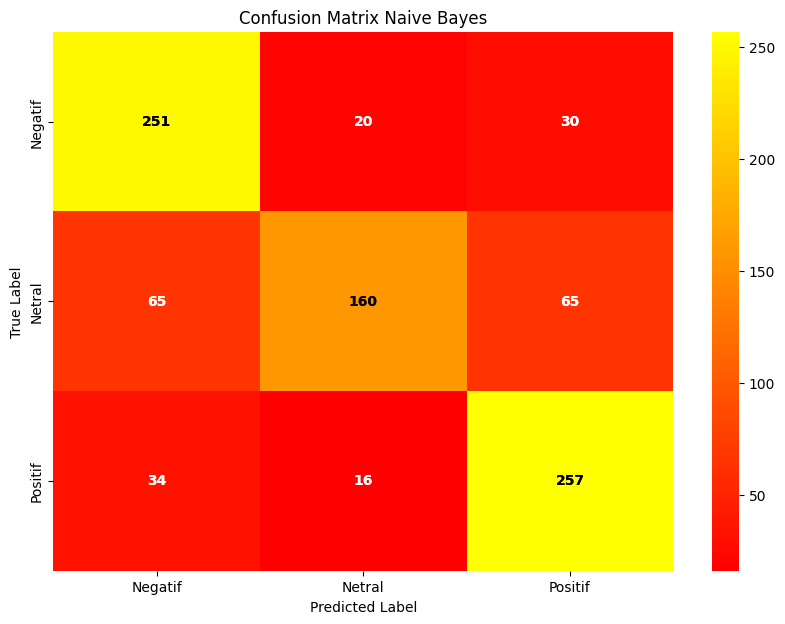

Confusion Matrix:
 [[251  20  30]
 [ 65 160  65]
 [ 34  16 257]]


In [61]:
X = data['stemming']
y = data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(f'Jumlah Data Latih: {len(X_train)}')
print(f'Jumlah Data Uji: {len(X_test)}')
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='autumn', xticklabels=model.classes_,
    yticklabels=model.classes_, annot_kws={"size": 10, "weight": "bold"}, cbar=True)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        color = 'white' if value < cm.max() / 2 else 'black'
        plt.text(j + 0.5, i + 0.5, str(value),
                 ha='center', va='center', color=color, fontsize=10, fontweight='bold')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Naive Bayes')
plt.show()
print("Confusion Matrix:\n", cm)

In [62]:
def class_accuracies(conf_matrix):
    true_positive = np.diag(conf_matrix)
    total_per_class = np.sum(conf_matrix, axis=1)
    accuracies = true_positive / total_per_class
    return accuracies
accuracies = class_accuracies(cm)
for label, acc in zip(model.classes_, accuracies):
    print(f'Akurasi Kelas {label}: {acc * 100:.2f}%')

Akurasi Kelas Negatif: 83.39%
Akurasi Kelas Netral: 55.17%
Akurasi Kelas Positif: 83.71%


In [63]:
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
threshold_list = [0.2, 0.1]

for test_size in threshold_list:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
results = pd.DataFrame({
    'Training Data Percentage': [80, 90],
    'Accuracy': accuracy_list, 'Precision': precision_list, 'Recall': recall_list, 'F1 Score': f1_list})
results.to_csv('result_NB_balancing.csv', index=False)
table_name = "result_nb_balancing"
results.to_sql(
    name=table_name, 
    con=engine, 
    if_exists='replace', 
    index=False
)
print(results)

   Training Data Percentage  Accuracy  Precision    Recall  F1 Score
0                        80  0.743875   0.753608  0.743875  0.737756
1                        90  0.732739   0.739713  0.732739  0.726841


In [64]:
report = classification_report(y_test, y_pred, output_dict=True)
report_data = pd.DataFrame(report).transpose()
print(report_data)

              precision    recall  f1-score     support
Negatif        0.723926  0.819444  0.768730  144.000000
Netral         0.787879  0.545455  0.644628  143.000000
Positif        0.711230  0.820988  0.762178  162.000000
accuracy       0.732739  0.732739  0.732739    0.732739
macro avg      0.741012  0.728629  0.725178  449.000000
weighted avg   0.739713  0.732739  0.726841  449.000000


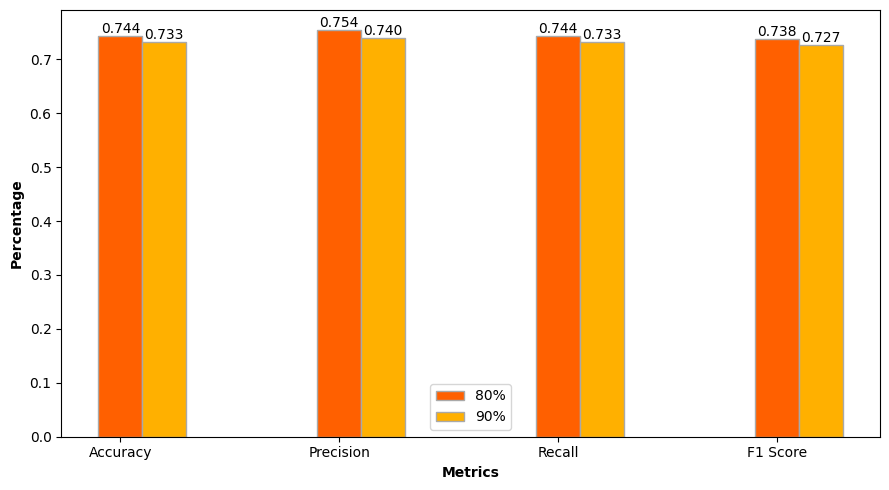

In [65]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values_80 = results[results['Training Data Percentage'] == 80].iloc[0, 1:].values
values_90 = results[results['Training Data Percentage'] == 90].iloc[0, 1:].values

bar_width = 0.2
r1 = np.arange(len(categories))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

plt.figure(figsize=(9, 5))
bars_80 = plt.bar(r2, values_80, color="#FF6000", width=bar_width, edgecolor='darkgrey', label='80%')
bars_90 = plt.bar(r3, values_90, color="#FFB000", width=bar_width, edgecolor='darkgrey', label='90%')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=10)
add_labels(bars_80)
add_labels(bars_90)

plt.xlabel('Metrics', fontweight='bold')
plt.ylabel('Percentage', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(categories))], categories)
plt.legend()
plt.tight_layout()
plt.show()

##### _Support Vector Machine_

Jumlah Data Latih: 3590
Jumlah Data Uji: 898

Accuracy: 0.8507795100222717
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.88      0.77      0.82       301
      Netral       0.79      0.90      0.84       290
     Positif       0.89      0.88      0.89       307

    accuracy                           0.85       898
   macro avg       0.85      0.85      0.85       898
weighted avg       0.86      0.85      0.85       898



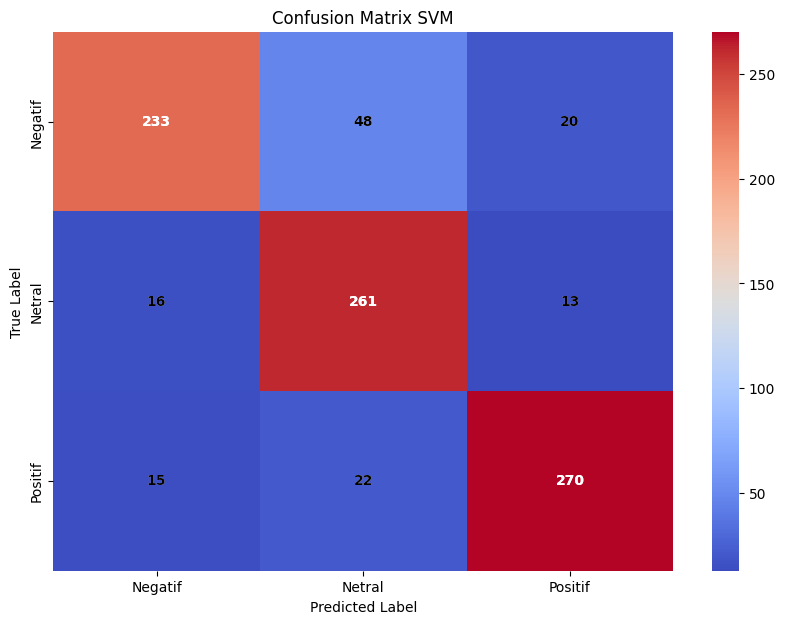

Confusion Matrix:
 [[233  48  20]
 [ 16 261  13]
 [ 15  22 270]]


In [66]:
X = data['stemming']
y = data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
model = SVC(kernel='linear', random_state=42)
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(f'Jumlah Data Latih: {len(X_train)}')
print(f'Jumlah Data Uji: {len(X_test)}')
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=model.classes_,
    yticklabels=model.classes_, annot_kws={"size": 10, "weight": "bold"}, cbar=True)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        color = 'black' if value < cm.max() / 2 else 'white'
        plt.text(j + 0.5, i + 0.5, str(value),
                 ha='center', va='center', color=color, fontsize=10, fontweight='bold')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix SVM')
plt.show()
print("Confusion Matrix:\n", cm)

In [67]:
def class_accuracies(conf_matrix):
    true_positive = np.diag(conf_matrix)
    total_per_class = np.sum(conf_matrix, axis=1)
    accuracies = true_positive / total_per_class
    return accuracies
accuracies = class_accuracies(cm)
for label, acc in zip(model.classes_, accuracies):
    print(f'Akurasi Kelas {label}: {acc * 100:.2f}%')

Akurasi Kelas Negatif: 77.41%
Akurasi Kelas Netral: 90.00%
Akurasi Kelas Positif: 87.95%


In [68]:
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
threshold_list = [0.2, 0.1]
vectorizer = CountVectorizer()
model = SVC(kernel='linear', random_state=42)

for test_size in threshold_list:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
results = pd.DataFrame({
    'Training Data Percentage': [100 - int(ts * 100) for ts in threshold_list],    'Accuracy': accuracy_list,
    'Precision': precision_list, 'Recall': recall_list,    'F1 Score': f1_list})
results.to_csv('result_svm_balancing.csv', index=False)
table_name = "result_svm_balancing"
results.to_sql(
    name=table_name, 
    con=engine, 
    if_exists='replace', 
    index=False
)
print(results)

   Training Data Percentage  Accuracy  Precision    Recall  F1 Score
0                        80  0.850780   0.855112  0.850780  0.850553
1                        90  0.870824   0.874639  0.870824  0.869823


In [69]:
report = classification_report(y_test, y_pred, output_dict=True)
report_data = pd.DataFrame(report).transpose()
print(report_data)

              precision    recall  f1-score     support
Negatif        0.887097  0.763889  0.820896  144.000000
Netral         0.812121  0.937063  0.870130  143.000000
Positif        0.918750  0.907407  0.913043  162.000000
accuracy       0.870824  0.870824  0.870824    0.870824
macro avg      0.872656  0.869453  0.868023  449.000000
weighted avg   0.874639  0.870824  0.869823  449.000000


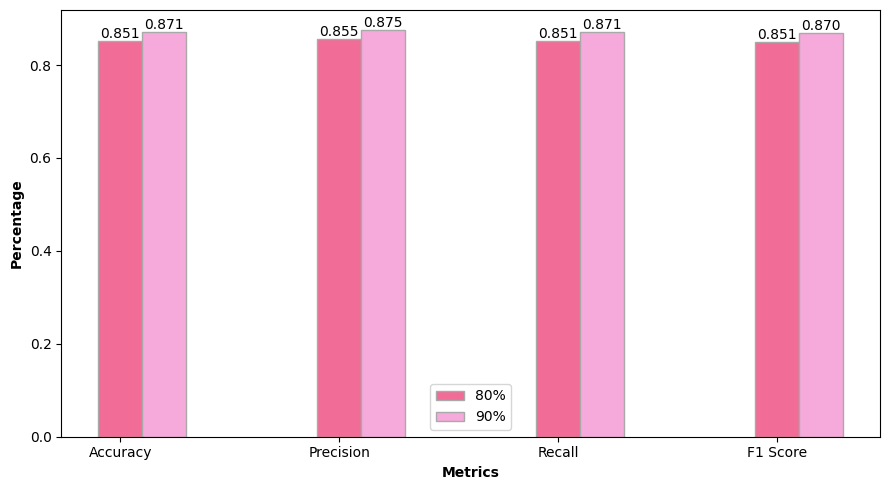

In [70]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values_80 = results[results['Training Data Percentage'] == 80].iloc[0, 1:].values
values_90 = results[results['Training Data Percentage'] == 90].iloc[0, 1:].values

bar_width = 0.2
r1 = np.arange(len(categories))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

plt.figure(figsize=(9, 5))
bars_80 = plt.bar(r2, values_80, color="#f16c96", width=bar_width, edgecolor='darkgrey', label='80%')
bars_90 = plt.bar(r3, values_90, color="#f5aadb", width=bar_width, edgecolor='darkgrey', label='90%')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=10)
add_labels(bars_80)
add_labels(bars_90)

plt.xlabel('Metrics', fontweight='bold')
plt.ylabel('Percentage', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(categories))], categories)
plt.legend()
plt.tight_layout()
plt.show()

##### _Long Short Term Memory_

Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 138ms/step - accuracy: 0.3503 - loss: 0.1564 - val_accuracy: 0.3092 - val_loss: -0.0725
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.3344 - loss: 0.0963 - val_accuracy: 0.3092 - val_loss: -0.0510
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.3464 - loss: 0.0869 - val_accuracy: 0.3092 - val_loss: -0.0707
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.3358 - loss: 0.0806 - val_accuracy: 0.3092 - val_loss: -0.0762
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 55s 505ms/step - accuracy: 0.3325 - loss: 0.0093 - val_accuracy: 0.3092 - val_loss: -0.0751
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step

Jumlah Data Latih: 3590
Jumlah Data Uji: 898

Accuracy: 0.32293986636971045
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00       301
      Netral       0.32      1.00      0.49       290
     Positif       0.00      0.00      0.00      

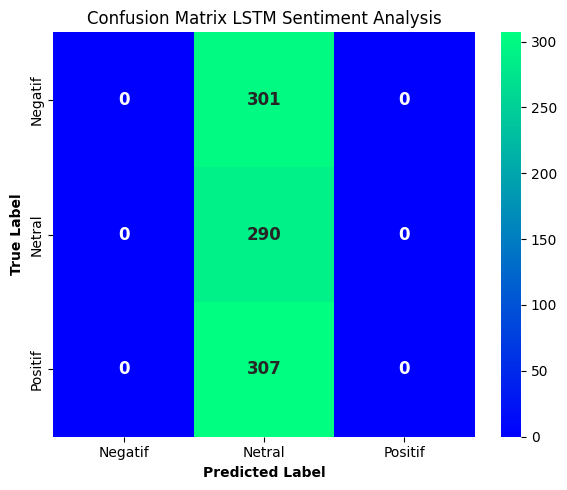


Confusion Matrix:
 [[  0 301   0]
 [  0 290   0]
 [  0 307   0]]


In [71]:
X = data['stemming'].astype(str)
y = data['sentiment']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

maxlen = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

model = Sequential([
    Embedding(input_dim=5000, output_dim=128),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=1)

y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(f'\nJumlah Data Latih: {len(X_train)}')
print(f'Jumlah Data Uji: {len(X_test)}')
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_,
                                                        zero_division=0))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='winter',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar=True, annot_kws={"size": 12, "weight": "bold"})

plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('Confusion Matrix LSTM Sentiment Analysis')
plt.tight_layout()
plt.show()
print("\nConfusion Matrix:\n", cm)

In [72]:
def class_accuracies(conf_matrix):
    true_positive = np.diag(conf_matrix)
    total_per_class = np.sum(conf_matrix, axis=1)
    accuracies = true_positive / total_per_class
    return accuracies

accuracies = class_accuracies(cm)
class_labels = ['Negatif', 'Netral', 'Positif']

for label, acc in zip(class_labels, accuracies):
    print(f'Akurasi Kelas {label}: {acc * 100:.2f}%')

Akurasi Kelas Negatif: 0.00%
Akurasi Kelas Netral: 100.00%
Akurasi Kelas Positif: 0.00%


In [73]:
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

threshold_list = [0.2, 0.1]

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

le = LabelEncoder()
y = le.fit_transform(y)

for test_size in threshold_list:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_test_seq = tokenizer.texts_to_sequences(X_test)
    X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
    X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post')

    vocab_size = len(tokenizer.word_index) + 1
    model = Sequential([
        Embedding(vocab_size, 128),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=0)

    y_pred_prob = model.predict(X_test_pad)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

results = pd.DataFrame({
    'Training Data Percentage': [100 - int(ts * 100) for ts in threshold_list],
    'Accuracy': accuracy_list,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1 Score': f1_list
})
results.to_csv('result_lstm_balancing.csv', index=False)
table_name = "result_lstm_balancing"
results.to_sql(
    name=table_name, 
    con=engine, 
    if_exists='replace', 
    index=False
)
print(results.to_string(index=False))

29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
 Training Data Percentage  Accuracy  Precision   Recall  F1 Score
                       80  0.322940   0.104290 0.322940  0.157664
                       90  0.318486   0.101433 0.318486  0.153863


In [74]:
report = classification_report(y_test, y_pred, output_dict=True)
report_data = pd.DataFrame(report).transpose()
print(report_data)

              precision    recall  f1-score     support
0              0.000000  0.000000  0.000000  144.000000
1              0.318486  1.000000  0.483108  143.000000
2              0.000000  0.000000  0.000000  162.000000
accuracy       0.318486  0.318486  0.318486    0.318486
macro avg      0.106162  0.333333  0.161036  449.000000
weighted avg   0.101433  0.318486  0.153863  449.000000


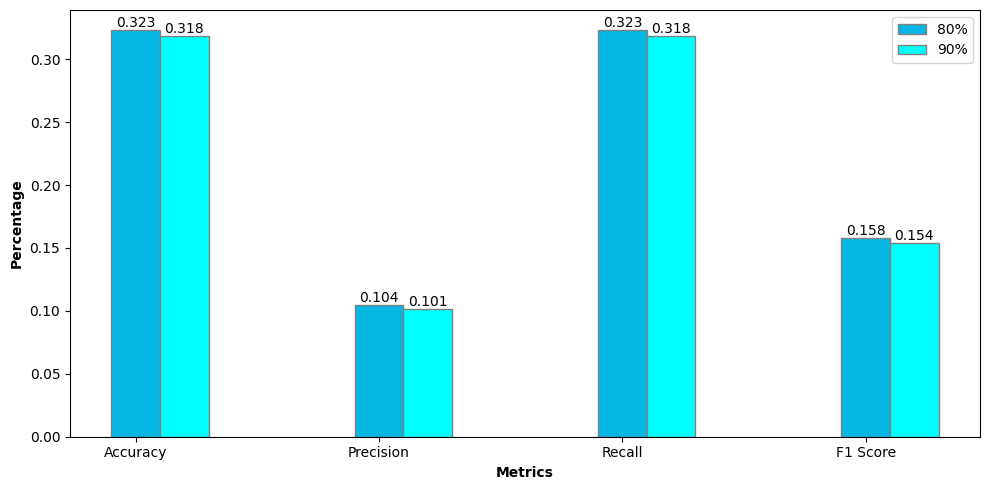

In [75]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values_80 = results[results['Training Data Percentage'] == 80].iloc[0, 1:].values
values_90 = results[results['Training Data Percentage'] == 90].iloc[0, 1:].values

bar_width = 0.2
r1 = np.arange(len(categories))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

plt.figure(figsize=(10, 5))
bars_80 = plt.bar(r2, values_80, color="#06B7E3", width=bar_width, edgecolor='grey', label='80%')
bars_90 = plt.bar(r3, values_90, color="#00FFFF", width=bar_width, edgecolor='grey', label='90%')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=10)
add_labels(bars_80)
add_labels(bars_90)

plt.xlabel('Metrics', fontweight='bold')
plt.ylabel('Percentage', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(categories))], categories)
plt.legend()
plt.tight_layout()
plt.show()

IDENTIFIKASI TOPIK

In [76]:
df_kw = pd.read_csv("topic_keywords.csv")

topic_keywords = {}
for _, row in df_kw.iterrows():
    topic = str(row["topic"]).lower().strip()
    keyword = str(row["keyword"]).lower().strip()

    if topic and keyword:
        topic_keywords.setdefault(topic, []).append(keyword)

topic_keywords = {
    topic: sorted(set(keywords), key=len, reverse=True)
    for topic, keywords in topic_keywords.items()
}

def clean_topic_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""

    text = re.sub(r"[^a-zA-Z\s]", " ", text.lower())
    text = re.sub(r"\s+", " ", text).strip()
    return text

def identify_topic_matching(text, return_score=False):
    text = clean_topic_text(text)
    if text == "":
        return (None, 0) if return_score else None

    topic_scores = {}
    for topic, keywords in topic_keywords.items():
        score = 0
        for keyword in keywords:
            keyword_clean = clean_topic_text(keyword)
            pattern = r"(?<!\w)" + re.escape(keyword_clean) + r"(?!\w)"
            if re.search(pattern, text):
                score += 1
        topic_scores[topic] = score

    best_topic = max(topic_scores, key=topic_scores.get)
    best_score = topic_scores[best_topic]
    result = best_topic if best_score > 0 else None
    return (result, best_score) if return_score else result

def build_lda_topic_result(text_series, topic_keywords):
    clean_texts = text_series.fillna("").astype(str).apply(clean_topic_text)
    valid_mask = clean_texts.str.strip().ne("")
    lda_result = pd.Series(index=text_series.index, dtype="object")

    if valid_mask.sum() == 0 or len(topic_keywords) == 0:
        return lda_result

    vectorizer = CountVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2))
    try:
        doc_term_matrix = vectorizer.fit_transform(clean_texts[valid_mask])
    except ValueError:
        vectorizer = CountVectorizer(max_df=1.0, min_df=1, ngram_range=(1, 2))
        doc_term_matrix = vectorizer.fit_transform(clean_texts[valid_mask])

    feature_names = vectorizer.get_feature_names_out()
    n_topics = len(topic_keywords)

    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch"
    )
    doc_topic_matrix = lda_model.fit_transform(doc_term_matrix)

    lda_topic_labels = {}
    for lda_idx, component in enumerate(lda_model.components_):
        top_word_indices = component.argsort()[:-16:-1]
        lda_words = [feature_names[i] for i in top_word_indices]
        lda_words_text = " ".join(lda_words)

        reference_scores = {}
        for topic, keywords in topic_keywords.items():
            score = sum(
                clean_topic_text(keyword) in lda_words_text
                for keyword in keywords
                if clean_topic_text(keyword)
            )
            reference_scores[topic] = score

        best_reference_topic = max(reference_scores, key=reference_scores.get)
        lda_topic_labels[lda_idx] = best_reference_topic if reference_scores[best_reference_topic] > 0 else None

    valid_indices = clean_texts[valid_mask].index
    dominant_topic_indices = doc_topic_matrix.argmax(axis=1)

    for row_index, lda_idx in zip(valid_indices, dominant_topic_indices):
        lda_result.loc[row_index] = lda_topic_labels[lda_idx]

    return lda_result

previous_topic_result = df["topic_result"].copy() if "topic_result" in df.columns else pd.Series(index=df.index, dtype="object")
if previous_topic_result.isna().all():
    for fallback_column in ["topic", "topik_result", "topic_keyword", "category"]:
        if fallback_column in df.columns:
            previous_topic_result = df[fallback_column]
            break

matching_info = df["stemming"].apply(lambda text: identify_topic_matching(text, return_score=True))
matching_result = matching_info.apply(lambda value: value[0])
matching_score = matching_info.apply(lambda value: value[1])
lda_result = build_lda_topic_result(df["stemming"], topic_keywords)

df["topic_result"] = matching_result.combine_first(lda_result).combine_first(previous_topic_result)
df["topic_compare"] = np.select(
    [
        matching_result.notna() & lda_result.notna() & matching_result.eq(lda_result),
        matching_result.notna() & lda_result.notna() & matching_result.ne(lda_result),
        matching_result.notna(),
        matching_result.isna() & lda_result.notna(),
    ],
    ["keyword = lda", "keyword preferred over lda", "keyword only", "lda fallback"],
    default="previous fallback"
)

if "topic" in df.columns:
    df["topic_result"] = df["topic_result"].fillna(df["topic"])

helper_columns = ["topic_keyword_matching", "topic_keyword_score", "topic_lda", "topic_previous"]
df = df.drop(columns=[col for col in helper_columns if col in df.columns])

df.to_csv("Identifikasi_topic.csv", index=False, encoding="utf-8-sig")
df

,video_id,author,comment,like_count,date,topic,year,normalization,tokenizing,stopword,stemming,category,sentiment,topic_result,topic_compare
0,JTEhv7JCRF0,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21T08:24:56Z,pengendalian hama,2025,bapa posisi di celegon klo di celegon saya pen...,"bapa, posisi, di, celegon, klo, di, celegon, s...","bapa, posisi, celegon, klo, celegon, pengin, s...","bapa, posisi, celegon, klo, celegon, pengin, s...",feedback penonton,Netral,pengendalian hama,previous fallback
1,JTEhv7JCRF0,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04T16:35:57Z,pengendalian hama,2026,itu bisa di campur dengan pupuk ultradap ndak,"itu, bisa, di, campur, dengan, pupuk, ultradap...","campur, pupuk, ultradap, ndak","campur, pupuk, ultradap, ndak",kompatibilitas pestisida,Netral,pengendalian hama,previous fallback
2,JTEhv7JCRF0,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03T13:47:10Z,pengendalian hama,2026,terima kasih pak atas pembekalan ilmunya semog...,"terima, kasih, pak, atas, pembekalan, ilmunya,...","terima, kasih, pembekalan, ilmunya, semoga, ke...","terima, kasih, bekal, ilmu, moga, luarga, sehat",feedback penonton,Positif,pengendalian hama,previous fallback
3,JTEhv7JCRF0,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama,2026,untuk dosis nya gimana pak,"untuk, dosis, nya, gimana, pak","dosis, nya, gimana","dosis, , gimana",kompatibilitas pestisida,Netral,pengendalian hama,previous fallback
4,JTEhv7JCRF0,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31T23:50:11Z,pengendalian hama,2025,maaf saya dari pandeglang alamat bapak di mana...,"maaf, saya, dari, pandeglang, alamat, bapak, d...","maaf, pandeglang, alamat, sy, belajar, tani, c...","maaf, pandeglang, alamat, sy, ajar, tani, cabai",feedback penonton,Negatif,pengendalian hama,previous fallback
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26065,zOKZCuwjWi8,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14T00:31:46Z,hidroponik,2025,pengendelaian hama menggunakan pestisida apa ka,"pengendelaian, hama, menggunakan, pestisida, a...","pengendelaian, hama, pestisida, ka","pengendelaian, hama, pestisida, ka",feedback penonton,Negatif,hidroponik,previous fallback
26066,zOKZCuwjWi8,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13T16:10:54Z,hidroponik,2025,blh apa enga bang saya minta cara taneman,"blh, apa, enga, bang, saya, minta, cara, taneman","blh, enga, bang, taneman","blh, enga, bang, taneman",feedback penonton,Netral,hidroponik,previous fallback
26067,zOKZCuwjWi8,@fashionshow2380,assalamualaikum bang,1,2025-04-13T16:09:49Z,hidroponik,2025,assalamualaikum bang,"assalamualaikum, bang","assalamualaikum, bang","assalamualaikum, bang",feedback penonton,Netral,hidroponik,previous fallback
26068,zOKZCuwjWi8,@TisaDamayanti-x3u,mksh ya,1,2025-04-13T14:38:14Z,hidroponik,2025,mksh ya,"mksh, ya","mksh, ya","mksh, ya",feedback penonton,Netral,hidroponik,previous fallback


In [ ]:
API_KEY = "YouTube API Key"
youtube = build("youtube", "v3", developerKey=API_KEY)

def get_video_details(video_id):
    try:
        request = youtube.videos().list(
            part="snippet",
            id=video_id
        )
        response = request.execute()
        items = response.get("items", [])
        
        if items and "snippet" in items[0]:
            snippet = items[0]["snippet"]
            return {
                "title": snippet.get("title"),
                "channel": snippet.get("channelTitle")
            }
        else:
            return {"title": None, "channel": None}
    except Exception as e:
        print(f"Error getting details for {video_id}: {e}")
        return {"title": None, "channel": None}

unique_ids = df["video_id"].unique()

details_map = {vid: get_video_details(vid) for vid in unique_ids}

df["title"] = df["video_id"].map(lambda x: details_map[x]["title"])
df["channel"] = df["video_id"].map(lambda x: details_map[x]["channel"])

cols = df.columns.tolist()
if "video_id" in cols:
    vid_index = cols.index("video_id")
    for col_name in ["channel", "title"]:
        if col_name in cols:
            cols.insert(vid_index + 1, cols.pop(cols.index(col_name)))
    df = df[cols]

df

,video_id,title,channel,author,comment,like_count,date,topic,year,normalization,tokenizing,stopword,stemming,category,sentiment,topic_result,topic_compare
0,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21T08:24:56Z,pengendalian hama,2025,bapa posisi di celegon klo di celegon saya pen...,"bapa, posisi, di, celegon, klo, di, celegon, s...","bapa, posisi, celegon, klo, celegon, pengin, s...","bapa, posisi, celegon, klo, celegon, pengin, s...",feedback penonton,Netral,pengendalian hama,previous fallback
1,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04T16:35:57Z,pengendalian hama,2026,itu bisa di campur dengan pupuk ultradap ndak,"itu, bisa, di, campur, dengan, pupuk, ultradap...","campur, pupuk, ultradap, ndak","campur, pupuk, ultradap, ndak",kompatibilitas pestisida,Netral,pengendalian hama,previous fallback
2,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03T13:47:10Z,pengendalian hama,2026,terima kasih pak atas pembekalan ilmunya semog...,"terima, kasih, pak, atas, pembekalan, ilmunya,...","terima, kasih, pembekalan, ilmunya, semoga, ke...","terima, kasih, bekal, ilmu, moga, luarga, sehat",feedback penonton,Positif,pengendalian hama,previous fallback
3,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03T07:08:08Z,pengendalian hama,2026,untuk dosis nya gimana pak,"untuk, dosis, nya, gimana, pak","dosis, nya, gimana","dosis, , gimana",kompatibilitas pestisida,Netral,pengendalian hama,previous fallback
4,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31T23:50:11Z,pengendalian hama,2025,maaf saya dari pandeglang alamat bapak di mana...,"maaf, saya, dari, pandeglang, alamat, bapak, d...","maaf, pandeglang, alamat, sy, belajar, tani, c...","maaf, pandeglang, alamat, sy, ajar, tani, cabai",feedback penonton,Negatif,pengendalian hama,previous fallback
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26065,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14T00:31:46Z,hidroponik,2025,pengendelaian hama menggunakan pestisida apa ka,"pengendelaian, hama, menggunakan, pestisida, a...","pengendelaian, hama, pestisida, ka","pengendelaian, hama, pestisida, ka",feedback penonton,Negatif,hidroponik,previous fallback
26066,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13T16:10:54Z,hidroponik,2025,blh apa enga bang saya minta cara taneman,"blh, apa, enga, bang, saya, minta, cara, taneman","blh, enga, bang, taneman","blh, enga, bang, taneman",feedback penonton,Netral,hidroponik,previous fallback
26067,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@fashionshow2380,assalamualaikum bang,1,2025-04-13T16:09:49Z,hidroponik,2025,assalamualaikum bang,"assalamualaikum, bang","assalamualaikum, bang","assalamualaikum, bang",feedback penonton,Netral,hidroponik,previous fallback
26068,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@TisaDamayanti-x3u,mksh ya,1,2025-04-13T14:38:14Z,hidroponik,2025,mksh ya,"mksh, ya","mksh, ya","mksh, ya",feedback penonton,Netral,hidroponik,previous fallback


In [88]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'] = df['date'].dt.date

ordered_columns = [
    'video_id', 'title', 'channel', 'author', 'comment', 'like_count', 'date', 'topic', 'year',
    'normalization', 'tokenizing', 'stopword', 'stemming', 'category',
    'sentiment', 'topic_result'
]

df = df[[col for col in ordered_columns if col in df.columns]]
df.to_csv("data/Hasil_Sentimen.csv", index=False, encoding="utf-8-sig")
print("Data berhasil disimpan ke CSV: data/Hasil_Sentimen.csv")

df.to_sql(
    "hasil_sentimen",
    engine,
    if_exists="replace",
    index=False
)

print("Data berhasil disimpan ke PostgreSQL")
df


Data berhasil disimpan ke CSV: data/Hasil_Sentimen.csv
Data berhasil disimpan ke PostgreSQL


,video_id,title,channel,author,comment,like_count,date,topic,year,normalization,tokenizing,stopword,stemming,category,sentiment,topic_result
0,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21,pengendalian hama,2025,bapa posisi di celegon klo di celegon saya pen...,"bapa, posisi, di, celegon, klo, di, celegon, s...","bapa, posisi, celegon, klo, celegon, pengin, s...","bapa, posisi, celegon, klo, celegon, pengin, s...",feedback penonton,Netral,pengendalian hama
1,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04,pengendalian hama,2026,itu bisa di campur dengan pupuk ultradap ndak,"itu, bisa, di, campur, dengan, pupuk, ultradap...","campur, pupuk, ultradap, ndak","campur, pupuk, ultradap, ndak",kompatibilitas pestisida,Netral,pengendalian hama
2,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03,pengendalian hama,2026,terima kasih pak atas pembekalan ilmunya semog...,"terima, kasih, pak, atas, pembekalan, ilmunya,...","terima, kasih, pembekalan, ilmunya, semoga, ke...","terima, kasih, bekal, ilmu, moga, luarga, sehat",feedback penonton,Positif,pengendalian hama
3,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03,pengendalian hama,2026,untuk dosis nya gimana pak,"untuk, dosis, nya, gimana, pak","dosis, nya, gimana","dosis, , gimana",kompatibilitas pestisida,Netral,pengendalian hama
4,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31,pengendalian hama,2025,maaf saya dari pandeglang alamat bapak di mana...,"maaf, saya, dari, pandeglang, alamat, bapak, d...","maaf, pandeglang, alamat, sy, belajar, tani, c...","maaf, pandeglang, alamat, sy, ajar, tani, cabai",feedback penonton,Negatif,pengendalian hama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26065,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14,hidroponik,2025,pengendelaian hama menggunakan pestisida apa ka,"pengendelaian, hama, menggunakan, pestisida, a...","pengendelaian, hama, pestisida, ka","pengendelaian, hama, pestisida, ka",feedback penonton,Negatif,hidroponik
26066,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13,hidroponik,2025,blh apa enga bang saya minta cara taneman,"blh, apa, enga, bang, saya, minta, cara, taneman","blh, enga, bang, taneman","blh, enga, bang, taneman",feedback penonton,Netral,hidroponik
26067,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@fashionshow2380,assalamualaikum bang,1,2025-04-13,hidroponik,2025,assalamualaikum bang,"assalamualaikum, bang","assalamualaikum, bang","assalamualaikum, bang",feedback penonton,Netral,hidroponik
26068,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@TisaDamayanti-x3u,mksh ya,1,2025-04-13,hidroponik,2025,mksh ya,"mksh, ya","mksh, ya","mksh, ya",feedback penonton,Netral,hidroponik


MODEL TERBAIK SETIAP VIDEO

In [89]:
def eval_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "accuracy": round(accuracy_score(y_test, y_pred), 2),
        "precision": round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 2),
        "recall": round(recall_score(y_test, y_pred, average="weighted", zero_division=0), 2),
        "f1-score": round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 2),
    }

def evaluate_video(df_vid):
    X = df_vid["comment"].astype(str)
    y = df_vid["sentiment"]

    if y.nunique() < 2 or min(y.value_counts()) < 2:
        return None

    tfidf = TfidfVectorizer()
    X_vec = tfidf.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_vec, y, test_size=0.2, random_state=42, stratify=y
    )

    nb = MultinomialNB()
    nb_scores = eval_model(nb, X_train, X_test, y_train, y_test)

    svm = LinearSVC(dual=False)
    svm_scores = eval_model(svm, X_train, X_test, y_train, y_test)

    try:
        X_lstm = df_vid["stemming"].astype(str)
        y_lstm = df_vid["sentiment"]

        label_enc = LabelEncoder()
        y_lstm_enc = label_enc.fit_transform(y_lstm)

        X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
            X_lstm, y_lstm_enc, test_size=0.2, random_state=42, stratify=y_lstm_enc
        )

        tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
        tokenizer.fit_on_texts(X_train_lstm)

        X_train_seq = tokenizer.texts_to_sequences(X_train_lstm)
        X_test_seq = tokenizer.texts_to_sequences(X_test_lstm)

        maxlen = 100
        X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding="post")
        X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding="post")

        model = Sequential([
            Embedding(input_dim=5000, output_dim=128),
            LSTM(128, dropout=0.3, recurrent_dropout=0.3),
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(1, activation='sigmoid')
        ])

        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

        model.fit(X_train_pad, y_train_lstm, epochs=3, batch_size=32, 
                  validation_split=0.2, verbose=0)

        y_pred_prob = model.predict(X_test_pad)
        y_pred_lstm = (y_pred_prob > 0.5).astype(int)

        lstm_scores = {
            "accuracy": round(accuracy_score(y_test_lstm, y_pred_lstm), 2),
            "precision": round(precision_score(y_test_lstm, y_pred_lstm, average="weighted", zero_division=0), 2),
            "recall": round(recall_score(y_test_lstm, y_pred_lstm, average="weighted", zero_division=0), 2),
            "f1-score": round(f1_score(y_test_lstm, y_pred_lstm, average="weighted", zero_division=0), 2),
        }
    except:
        
        lstm_scores = None

    scores = {
        "Naive Bayes": nb_scores,
        "SVM": svm_scores,
        "LSTM": lstm_scores
    }

    scores = {k: v for k, v in scores.items() if v is not None}

    best = sorted(
        scores.items(),
        key=lambda x: (x[1]["f1-score"], x[1]["accuracy"]),
        reverse=True
    )[0]

    model_name, metric = best
    metric["model_used"] = model_name

    return metric

best_models = {}

for vid, group in df.groupby("video_id"):
    result = evaluate_video(group)
    if result is not None:
        best_models[vid] = result

df_final = df.copy()

df_final["model_used"] = df_final["video_id"].map(lambda x: best_models.get(x, {}).get("model_used"))
df_final["accuracy"] = df_final["video_id"].map(lambda x: best_models.get(x, {}).get("accuracy"))
df_final["precision"] = df_final["video_id"].map(lambda x: best_models.get(x, {}).get("precision"))
df_final["recall"] = df_final["video_id"].map(lambda x: best_models.get(x, {}).get("recall"))
df_final["f1-score"] = df_final["video_id"].map(lambda x: best_models.get(x, {}).get("f1-score"))

ordered_columns = [
    'video_id', 'title', 'channel', 'author', 'comment', 'like_count', 'date', 'year', 'normalization','tokenizing', 'stopword', 
    'stemming', 'category', 'sentiment', 'model_used', 'accuracy', 'precision', 'recall', 'f1-score', 'topic', 'topic_result'
]

df_final = df_final.reindex(columns=ordered_columns)
df_final.to_csv("data/Hasil_Best_Model_Setiap_Video.csv", index=False, encoding="utf-8-sig")
df_final.to_sql(
    "hasil_best_model_video",   
    engine,
    if_exists="replace",        
    index=False,
    method="multi"              
)

print("Data berhasil disimpan ke PostgreSQL (tabel: hasil_best_model_video)")
df_final

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 462ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 398ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step  
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 358ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━

,video_id,title,channel,author,comment,like_count,date,year,normalization,tokenizing,...,stemming,category,sentiment,model_used,accuracy,precision,recall,f1-score,topic,topic_result
0,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@iingfatmawati3471,bapa posisi di celegon klo di celegon saya pen...,31,2025-05-21,2025,bapa posisi di celegon klo di celegon saya pen...,"bapa, posisi, di, celegon, klo, di, celegon, s...",...,"bapa, posisi, celegon, klo, celegon, pengin, s...",feedback penonton,Netral,SVM,0.87,0.88,0.87,0.87,pengendalian hama,pengendalian hama
1,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@RohmatSaputra-zg1hf,itu bisa di campur dengan pupuk ultradap ndak,0,2026-01-04,2026,itu bisa di campur dengan pupuk ultradap ndak,"itu, bisa, di, campur, dengan, pupuk, ultradap...",...,"campur, pupuk, ultradap, ndak",kompatibilitas pestisida,Netral,SVM,0.87,0.88,0.87,0.87,pengendalian hama,pengendalian hama
2,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@Yoss-m5x,terima kasih pak atas pembekalan ilmunya semog...,0,2026-01-03,2026,terima kasih pak atas pembekalan ilmunya semog...,"terima, kasih, pak, atas, pembekalan, ilmunya,...",...,"terima, kasih, bekal, ilmu, moga, luarga, sehat",feedback penonton,Positif,SVM,0.87,0.88,0.87,0.87,pengendalian hama,pengendalian hama
3,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@DedyAjah-j2k5w,untuk dosis nya gimana pak,0,2026-01-03,2026,untuk dosis nya gimana pak,"untuk, dosis, nya, gimana, pak",...,"dosis, , gimana",kompatibilitas pestisida,Netral,SVM,0.87,0.88,0.87,0.87,pengendalian hama,pengendalian hama
4,JTEhv7JCRF0,PENGENDALIAN HAMA & PENYAKIT CABE,SELMA FARM,@AkangJalu-r8s,maaf saya dari pandeglang alamat bapak di mana...,0,2025-12-31,2025,maaf saya dari pandeglang alamat bapak di mana...,"maaf, saya, dari, pandeglang, alamat, bapak, d...",...,"maaf, pandeglang, alamat, sy, ajar, tani, cabai",feedback penonton,Negatif,SVM,0.87,0.88,0.87,0.87,pengendalian hama,pengendalian hama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26065,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@natatatatatatta4671,pengendelaian hama menggunakan pestisida apa ka,1,2025-04-14,2025,pengendelaian hama menggunakan pestisida apa ka,"pengendelaian, hama, menggunakan, pestisida, a...",...,"pengendelaian, hama, pestisida, ka",feedback penonton,Negatif,SVM,0.79,0.81,0.79,0.76,hidroponik,hidroponik
26066,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@fashionshow2380,blh apa enga bang saya minta cara taneman,1,2025-04-13,2025,blh apa enga bang saya minta cara taneman,"blh, apa, enga, bang, saya, minta, cara, taneman",...,"blh, enga, bang, taneman",feedback penonton,Netral,SVM,0.79,0.81,0.79,0.76,hidroponik,hidroponik
26067,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@fashionshow2380,assalamualaikum bang,1,2025-04-13,2025,assalamualaikum bang,"assalamualaikum, bang",...,"assalamualaikum, bang",feedback penonton,Netral,SVM,0.79,0.81,0.79,0.76,hidroponik,hidroponik
26068,zOKZCuwjWi8,Menanam Sayuran Hidroponik Pemula Di Lahan Ter...,Januri Nurhidayat,@TisaDamayanti-x3u,mksh ya,1,2025-04-13,2025,mksh ya,"mksh, ya",...,"mksh, ya",feedback penonton,Netral,SVM,0.79,0.81,0.79,0.76,hidroponik,hidroponik


In [90]:
all_video_ids = [
        'JTEhv7JCRF0', 'GzdFV_r-SHM', 'JL2VZdA9wuc', 'Xrbn47ZiFYw',
       'M0KYwjW-22c', 'bOsToXOFK4A', '_lAVXCvou78', 'pO43PBserhU',
       'Z3QfdLBjRWk', '28Eo_Xm8LYg', 'UfbQxFXre5Q', 'inF984LZKa0',
       'TCRV_d27iG0', '-YlHpqcgOow', 'QQM9BKY0_K8', '4CTYII_qHCQ',
       'kS16kRKYJGg', 'CKlWtn_c7Es', '59vXGu65IS4', 'AQLcjhHQBC0',
       'i86gVDwhNzg', 'MGpF_mdUVTg', 'e0SHDMs4bDk', '_99fDKfRq50',
       'YxYvJhEqC98', '3MeyTr2kdBg', '5Fv2tGv9_Vo', 'vvcBT2Fg5IQ',
       'ucfHy84xvec', 'iArT8RhBxzY', 'ypbdbIGDYGw', 'G1MjF639DrY',
       '1NnDgJzBAq4', 'mLdvwruqEpo', 'DcG3sqwpSa0', 'GO6PuKMedeM',
       '9zyK_C4g4qU', '-GyJN1tr9RM', 'y5B5sxJYEOI', 'zOKZCuwjWi8'
]

valid_acc = [v["accuracy"] for v in best_models.values() if v.get("accuracy") is not None]
valid_f1 = [v["f1-score"] for v in best_models.values() if v.get("f1-score") is not None]
valid_models = [v["model_used"] for v in best_models.values() if v.get("model_used")]

avg_accuracy = round(np.mean(valid_acc), 2)
avg_f1 = round(np.mean(valid_f1), 2)
dominant_model = Counter(valid_models).most_common(1)[0][0]

results_list = []

for vid in all_video_ids:
    metric = best_models.get(vid)

    if metric:
        model_name = metric["model_used"]
        acc = round(metric["accuracy"], 2)
        f1 = round(metric["f1-score"], 2)
    else:
        model_name = dominant_model
        acc = avg_accuracy
        f1 = avg_f1

    results_list.append([vid, model_name, acc, f1])

df_best = pd.DataFrame(
    results_list,
    columns=["video_id", "model_used", "accuracy", "f1-score"]
)

display(df_best)

,video_id,model_used,accuracy,f1-score
0,JTEhv7JCRF0,SVM,0.87,0.87
1,GzdFV_r-SHM,SVM,0.88,0.87
2,JL2VZdA9wuc,SVM,0.82,0.80
3,Xrbn47ZiFYw,SVM,0.87,0.86
4,M0KYwjW-22c,SVM,0.83,0.82
5,bOsToXOFK4A,SVM,0.86,0.84
6,_lAVXCvou78,SVM,0.88,0.87
7,pO43PBserhU,SVM,0.82,0.79
8,Z3QfdLBjRWk,SVM,0.83,0.82
9,28Eo_Xm8LYg,SVM,0.89,0.89


In [91]:
model_counts = df_best["model_used"].value_counts()

print("Distribusi Model:")
model_counts

Distribusi Model:


model_used
SVM            39
Naive Bayes     1
Name: count, dtype: int64

APP_ASSETS

In [84]:
engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

images_to_upload = {
    "Perkebunan-Rakyat.jpeg": "bg_perkebunan_rakyat",
    "bibit.png": "image_bibit",
    "emotional.png": "icon_sentiment",
    "dashboard.png": "icon_dashboard",
    "smile.png": "icon_smile",
    "sad.png": "icon_sad",
    "neutral.png": "icon_neutral",
    "classification.png": "icon_classification",
    "realtime.png": "icon_realtime"
}

table_name = "app_assets"
uploaded_count = 0

print("Memulai proses upload aset gambar ke PostgreSQL...")
print("-" * 50)

for file_name, asset_name in images_to_upload.items():
    if os.path.exists(file_name):
        try:
            with open(file_name, "rb") as f:
                binary_data = f.read()
            
            df_img = pd.DataFrame([{
                'name': asset_name,
                'image_data': binary_data,
                'file_type': 'png'
            }])
            
            df_img.to_sql(
                name=table_name, 
                con=engine, 
                if_exists='append', 
                index=False
            )
            print(f"[SUKSES] File '{file_name}' disimpan sebagai aset: '{asset_name}'")
            uploaded_count += 1
            
        except Exception as e:
            print(f"[GAGAL] Gagal mengunggah file '{file_name}': {e}")
    else:
        print(f"[PERINGATAN] File '{file_name}' tidak ditemukan di folder lokal Anda.")

print("-" * 50)
print(f"Proses selesai. {uploaded_count} gambar berhasil masuk ke database tabel '{table_name}'.")

Memulai proses upload aset gambar ke PostgreSQL...
--------------------------------------------------
[SUKSES] File 'Perkebunan-Rakyat.jpeg' disimpan sebagai aset: 'bg_perkebunan_rakyat'
[SUKSES] File 'bibit.png' disimpan sebagai aset: 'image_bibit'
[SUKSES] File 'emotional.png' disimpan sebagai aset: 'icon_sentiment'
[SUKSES] File 'dashboard.png' disimpan sebagai aset: 'icon_dashboard'
[SUKSES] File 'smile.png' disimpan sebagai aset: 'icon_smile'
[SUKSES] File 'sad.png' disimpan sebagai aset: 'icon_sad'
[SUKSES] File 'neutral.png' disimpan sebagai aset: 'icon_neutral'
[SUKSES] File 'classification.png' disimpan sebagai aset: 'icon_classification'
[SUKSES] File 'realtime.png' disimpan sebagai aset: 'icon_realtime'
--------------------------------------------------
Proses selesai. 9 gambar berhasil masuk ke database tabel 'app_assets'.
